# FINAL1D.ipynb

This notebook is the inference-only side of the daily workflow. It expects `Final1DTrain.ipynb` to have already created `output/final_1d_artifacts/manifest.json` plus all forecast checkpoints, scaler stats, feature manifests, ensemble weights, and PPO artifacts.

The notebook loads those frozen artifacts, fetches the latest daily market data, runs the forecast experts one at a time, shows each expert prediction, builds the weighted aggregate forecast, runs the saved `v9.6` decision layer on top, and includes a strictly causal rolling daily backtest driven by the frozen ensemble.


In [1]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = {
    "alpaca.data": "alpaca-py",
    "pandas_market_calendars": "pandas-market-calendars",
    "pyarrow": "pyarrow",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "tqdm": "tqdm",
}


def module_available(module_name: str) -> bool:
    try:
        importlib.import_module(module_name)
        return True
    except Exception:
        return False


missing = [package for module_name, package in REQUIRED_PACKAGES.items() if not module_available(module_name)]
if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Required packages already available.")

if not module_available("torch"):
    print("Installing missing package: torch")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch"])
else:
    print("torch already available.")


Required packages already available.
torch already available.


In [2]:
import gc
import json
import math
import os
import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import torch
import torch.nn as nn
import torch.nn.functional as F
from alpaca.data.enums import DataFeed
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from IPython.display import display
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib import pyplot as plt
from matplotlib.patches import Patch, Rectangle
from tqdm import tqdm


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LOW_VRAM_GPU = DEVICE.type == "cuda" and (torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)) <= 8.5
RUN_LABEL = pd.Timestamp.now(tz="UTC").strftime("%Y%m%d_%H%M%S")

SYMBOL = "MSFT"
LOOKBACK_DAYS = 3650
HORIZON = 7
SESSION_TZ = "America/New_York"
SESSION_OPEN_SKIP_BARS = 0
REQUEST_CHUNK_DAYS = 365
MAX_REQUESTS_PER_MINUTE = 120
MAX_RETRIES = 5
ACTION_NEUTRAL_BAND = 0.10
SAVE_RUN_OUTPUTS = True
FINAL_ROLLING_STEP = 1
FINAL_ROLLING_BACKTEST_DATE = None
FINAL_ROLLING_WINDOW = 60
FINAL_ROLLING_HISTORY_BARS = 180
FINAL_ROLLING_SAVE_FRAMES = False
FINAL_ROLLING_DISPLAY_FRAME_INDEX = -1
FINAL_ROLLING_USE_CPU_ON_LOW_VRAM = LOW_VRAM_GPU
FINAL_ROLLING_DEVICE = torch.device("cpu") if FINAL_ROLLING_USE_CPU_ON_LOW_VRAM else DEVICE
FINAL_ROLLING_CLEAR_EVERY = 24
FINAL_WEIGHT_PRIOR_BLEND = 0.0
FINAL_EXCLUDED_EXPERTS = set()
FINAL_AGGREGATION_WEIGHT_PRIOR = {
    "v8_5": 0.33,
    "v9_2": 0.33,
    "v9_5": 0.34,
}
FINAL_AGGREGATE_SHRINK = 0.85
FINAL_SOFT_SWING_GUARD_ENABLED = True
FINAL_SOFT_SWING_GUARD_LOOKBACK = 252
FINAL_SOFT_SWING_GUARD_Q95_MULT = 1.35
FINAL_SOFT_SWING_GUARD_ATR_MULT = 0.75
FINAL_SOFT_SWING_GUARD_MIN_MOVE = 0.50
FINAL_SOFT_SWING_GUARD_EXCESS_SCALE = 0.20
FINAL_SOFT_SWING_GUARD_HARD_MULT = 1.15
FINAL_SOFT_SWING_GUARD_EXTREME_SCALE = 0.02
FINAL_EMPIRICAL_ENVELOPE_ENABLED = True
FINAL_EMPIRICAL_ENVELOPE_LOOKBACK = 252
FINAL_EMPIRICAL_ENVELOPE_Q95_MULT = 1.20
FINAL_EMPIRICAL_ENVELOPE_STEP_BASE_MULT = 1.00
FINAL_EMPIRICAL_ENVELOPE_ATR_MULT = 0.75
FINAL_EMPIRICAL_ENVELOPE_MIN_MOVE = 0.50
FINAL_EMPIRICAL_ENVELOPE_EXCESS_SCALE = 0.16
FINAL_EMPIRICAL_ENVELOPE_HARD_MULT = 1.12
FINAL_EMPIRICAL_ENVELOPE_EXTREME_SCALE = 0.02
FINAL_CANDLE_RANGE_GUARD_ENABLED = True
FINAL_CANDLE_RANGE_GUARD_LOOKBACK = 252
FINAL_CANDLE_RANGE_GUARD_Q97_MULT = 1.50
FINAL_CANDLE_RANGE_GUARD_MIN_WICK = 0.60
FINAL_AGGREGATE_GUARD_LOOKBACK = max(
    FINAL_SOFT_SWING_GUARD_LOOKBACK,
    FINAL_EMPIRICAL_ENVELOPE_LOOKBACK,
    FINAL_CANDLE_RANGE_GUARD_LOOKBACK,
)
FINAL_T1_TEMPORAL_GUARD_ENABLED = True
FINAL_T1_TEMPORAL_GUARD_LOOKBACK = 252
FINAL_T1_TEMPORAL_Q95_MULT = 1.20
FINAL_T1_TEMPORAL_ATR_MULT = 0.60
FINAL_T1_TEMPORAL_MIN_MOVE = 0.50
FINAL_T1_TEMPORAL_EXCESS_SCALE = 0.14
FINAL_T1_TEMPORAL_HARD_MULT = 1.12
FINAL_T1_TEMPORAL_EXTREME_SCALE = 0.00
FINAL_T1_TEMPORAL_RECAP_EXCESS_SCALE = 0.10
FINAL_T1_TEMPORAL_RECAP_HARD_MULT = 1.08
FINAL_T1_TEMPORAL_RECAP_EXTREME_SCALE = 0.00
FINAL_T1_DIRECTION_GUARD_ENABLED = True
FINAL_T1_DIRECTION_VOTE_THRESHOLD = 0.35
FINAL_T1_DIRECTION_MOMENTUM_BARS = 3
FINAL_T1_DIRECTION_MOMENTUM_MIN_MOVE = 0.15
FINAL_T1_DIRECTION_MAX_ABS_DELTA_TO_OVERRIDE = 0.80
FINAL_T1_DIRECTION_MIN_OVERRIDE_MOVE = 0.15
FINAL_T1_DIRECTION_MAX_OVERRIDE_MOVE = 0.60
FINAL_T1_SHIFT_FADE_POWER = 2.0

TARGET_COLUMNS = ["rOpen", "rHigh", "rLow", "rClose"]
CORE_FEATURE_COLUMNS = [
    "rOpen",
    "rHigh",
    "rLow",
    "rClose",
    "logVolChange",
    "logTradeCountChange",
    "vwapDelta",
    "rangeFrac",
    "orderFlowProxy",
    "tickPressure",
]
TECHNICAL_FEATURE_COLUMNS = [
    "sma_5",
    "sma_10",
    "sma_20",
    "sma_50",
    "ema_12",
    "ema_26",
    "macd_line",
    "macd_signal",
    "macd_histogram",
    "macd_momentum",
    "rsi_14",
    "rsi_14_slope",
    "stoch_k",
    "stoch_d",
    "bb_upper",
    "bb_lower",
    "bb_width",
    "bb_position",
    "atr_14",
    "atr_14_pct",
    "obv",
    "obv_slope",
    "vwap_20",
    "vwap_20_dev",
    "price_momentum_5",
    "price_momentum_10",
    "price_momentum_20",
    "body_size",
    "body_pct",
    "upper_shadow",
    "lower_shadow",
    "direction",
]
REGIME_FEATURE_COLUMNS = [
    "atr_14",
    "atr_14_pct",
    "returns",
    "turbulence_60",
    "regime_indicator",
]
MARKET_STATE_COLUMNS = [
    "rsi_14",
    "macd_histogram",
    "bb_position",
    "atr_14_pct",
    "price_momentum_5",
    "price_momentum_20",
    "vwap_20_dev",
    "obv_slope",
    "direction",
    "relative_volume",
]
EXPECTED_EXPERTS: List[str] = []

ARTIFACT_ROOT = Path("output/final_1d_artifacts")
MANIFEST_PATH = ARTIFACT_ROOT / "manifest.json"
FINAL_RUN_DIR = Path("output/final_1d_runs") / RUN_LABEL

PORTFOLIO_STATE = {
    "cash_norm": 1.0,
    "shares_norm": 0.0,
    "portfolio_value_norm": 1.0,
    "position_pct": 0.0,
}

print(
    {
        "device": str(DEVICE),
        "low_vram_gpu": LOW_VRAM_GPU,
        "manifest_path": str(MANIFEST_PATH),
        "run_label": RUN_LABEL,
        "save_run_outputs": SAVE_RUN_OUTPUTS,
        "final_rolling_window": FINAL_ROLLING_WINDOW,
        "final_rolling_save_frames": FINAL_ROLLING_SAVE_FRAMES,
        "final_rolling_device": str(FINAL_ROLLING_DEVICE),
        "final_weight_prior_blend": FINAL_WEIGHT_PRIOR_BLEND,
        "final_excluded_experts": sorted(FINAL_EXCLUDED_EXPERTS),
        "final_aggregate_shrink": FINAL_AGGREGATE_SHRINK,
        "final_soft_swing_guard_enabled": FINAL_SOFT_SWING_GUARD_ENABLED,
        "final_soft_swing_guard_lookback": FINAL_SOFT_SWING_GUARD_LOOKBACK,
        "final_empirical_envelope_lookback": FINAL_EMPIRICAL_ENVELOPE_LOOKBACK,
        "final_candle_range_guard_lookback": FINAL_CANDLE_RANGE_GUARD_LOOKBACK,
        "final_t1_temporal_guard_lookback": FINAL_T1_TEMPORAL_GUARD_LOOKBACK,
    }
)


{'device': 'cuda', 'low_vram_gpu': True, 'manifest_path': 'output\\final_1d_artifacts\\manifest.json', 'run_label': '20260422_214849', 'save_run_outputs': True, 'final_rolling_window': 60, 'final_rolling_save_frames': False, 'final_rolling_device': 'cpu', 'final_weight_prior_blend': 0.0, 'final_excluded_experts': [], 'final_aggregate_shrink': 0.85, 'final_soft_swing_guard_enabled': True, 'final_soft_swing_guard_lookback': 252, 'final_empirical_envelope_lookback': 252, 'final_candle_range_guard_lookback': 252, 'final_t1_temporal_guard_lookback': 252}


In [4]:
def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def clear_torch_memory() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        if hasattr(torch.cuda, "ipc_collect"):
            torch.cuda.ipc_collect()


def production_timestamp_utc() -> str:
    return pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ")


def load_json(path: Path) -> Dict[str, Any]:
    return json.loads(path.read_text(encoding="utf-8"))


def to_serializable(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(k): to_serializable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_serializable(v) for v in value]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, pd.Timestamp):
        return value.isoformat()
    if isinstance(value, (np.floating, np.integer)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    return value


def save_json(path: Path, payload: Dict[str, Any]) -> None:
    path.write_text(json.dumps(to_serializable(payload), indent=2), encoding="utf-8")


def save_npz(path: Path, **arrays: Any) -> None:
    np.savez_compressed(path, **arrays)


def save_dataframe(df: pd.DataFrame, path: Path) -> None:
    if path.suffix.lower() == ".csv":
        df.to_csv(path, index=False)
    else:
        df.to_parquet(path, index=False)


def fail_if_missing(path: Path, message: str) -> None:
    if not path.exists():
        raise FileNotFoundError(f"{message}: {path}")


def feature_columns_for_mode(mode: str) -> List[str]:
    if mode == "core":
        return CORE_FEATURE_COLUMNS.copy()
    if mode == "technical":
        return CORE_FEATURE_COLUMNS + TECHNICAL_FEATURE_COLUMNS
    if mode == "regime":
        return CORE_FEATURE_COLUMNS + REGIME_FEATURE_COLUMNS
    raise ValueError(f"Unsupported feature mode: {mode}")


def apply_input_scaler(x: np.ndarray, scaler: Dict[str, np.ndarray]) -> np.ndarray:
    return ((x - scaler["mean"]) / scaler["std"]).astype(np.float32)


def enforce_candle_validity(path: np.ndarray) -> np.ndarray:
    repaired = np.asarray(path, dtype=np.float32).copy()
    repaired[:, 1] = np.maximum(repaired[:, 1], np.maximum(repaired[:, 0], repaired[:, 3]))
    repaired[:, 2] = np.minimum(repaired[:, 2], np.minimum(repaired[:, 0], repaired[:, 3]))
    return repaired


def returns_to_prices_seq(anchor_prev_close: float, return_seq: np.ndarray) -> np.ndarray:
    prices = np.zeros_like(return_seq, dtype=np.float32)
    prev_close = float(anchor_prev_close)
    for step in range(return_seq.shape[0]):
        prices[step] = np.exp(return_seq[step]) * prev_close
        prev_close = float(prices[step, 3])
    return enforce_candle_validity(prices)


def normalize_weight_map(weight_map: Dict[str, float], experts: Sequence[str]) -> Dict[str, float]:
    filtered = {expert: max(0.0, float(weight_map.get(expert, 0.0))) for expert in experts}
    total = sum(filtered.values())
    if total <= 0.0:
        uniform = 1.0 / max(len(experts), 1)
        return {expert: uniform for expert in experts}
    return {expert: value / total for expert, value in filtered.items()}


def build_final_inference_weights(saved_weights: Dict[str, float], experts: Sequence[str]) -> Dict[str, float]:
    saved_norm = normalize_weight_map(saved_weights, experts)
    prior_raw = {
        expert: float(FINAL_AGGREGATION_WEIGHT_PRIOR.get(expert, saved_norm.get(expert, 0.0)))
        for expert in experts
    }
    prior_norm = normalize_weight_map(prior_raw, experts)
    blended = {
        expert: (1.0 - FINAL_WEIGHT_PRIOR_BLEND) * saved_norm[expert] + FINAL_WEIGHT_PRIOR_BLEND * prior_norm[expert]
        for expert in experts
    }
    return normalize_weight_map(blended, experts)


def shrink_path_to_anchor(path: np.ndarray, anchor_prev_close: float, shrink: float) -> np.ndarray:
    if not 0.0 < float(shrink) <= 1.0:
        raise ValueError(f"Shrink factor must be in (0, 1], got {shrink}")
    anchor = float(anchor_prev_close)
    shrunk = anchor + float(shrink) * (np.asarray(path, dtype=np.float32) - anchor)
    return enforce_candle_validity(shrunk.astype(np.float32))


def build_guard_history_slice(feature_df: pd.DataFrame, anchor_index: int, lookback: int) -> pd.DataFrame:
    end = max(0, int(anchor_index))
    start = max(0, end - int(lookback))
    if end <= start:
        return feature_df.iloc[max(0, end - 1) : end].copy()
    return feature_df.iloc[start:end].copy()


def _latest_atr_value(history_slice: pd.DataFrame) -> float:
    if history_slice.empty:
        return 0.0
    if "atr_14" in history_slice.columns:
        atr_series = pd.Series(history_slice["atr_14"], dtype="float64").replace([np.inf, -np.inf], np.nan).ffill().bfill()
        if len(atr_series) > 0 and pd.notna(atr_series.iloc[-1]):
            return float(atr_series.iloc[-1])

    if not {"high", "low", "close"}.issubset(history_slice.columns):
        return 0.0

    if "prev_close" in history_slice.columns:
        prev_close = pd.Series(history_slice["prev_close"], dtype="float64").copy()
    else:
        prev_close = pd.Series(history_slice["close"], dtype="float64").shift(1)
        if len(prev_close) > 0:
            fallback = float(history_slice["open"].iloc[0]) if "open" in history_slice.columns else float(history_slice["close"].iloc[0])
            prev_close.iloc[0] = fallback

    tr_components = pd.concat(
        [
            (pd.Series(history_slice["high"], dtype="float64") - pd.Series(history_slice["low"], dtype="float64")).abs(),
            (pd.Series(history_slice["high"], dtype="float64") - prev_close).abs(),
            (pd.Series(history_slice["low"], dtype="float64") - prev_close).abs(),
        ],
        axis=1,
    )
    atr_series = tr_components.max(axis=1).rolling(14, min_periods=1).mean()
    atr_series = atr_series.replace([np.inf, -np.inf], np.nan).ffill().bfill()
    return float(atr_series.iloc[-1]) if len(atr_series) > 0 else 0.0


def compute_soft_swing_guard_cap(history_slice: pd.DataFrame) -> float:
    if history_slice.empty:
        return float(FINAL_SOFT_SWING_GUARD_MIN_MOVE)

    if "prev_close" in history_slice.columns:
        prev_close = history_slice["prev_close"].astype(float).copy()
    else:
        prev_close = history_slice["close"].shift(1).astype(float)
        if len(prev_close) > 0:
            fallback = float(history_slice["open"].iloc[0]) if "open" in history_slice.columns else float(history_slice["close"].iloc[0])
            prev_close.iloc[0] = fallback

    abs_close_move = (history_slice["close"].astype(float) - prev_close).abs()
    abs_close_move = abs_close_move.replace([np.inf, -np.inf], np.nan).dropna()
    q95_move = float(abs_close_move.quantile(0.95)) if len(abs_close_move) > 0 else 0.0

    atr_value = _latest_atr_value(history_slice)

    return float(
        max(
            FINAL_SOFT_SWING_GUARD_MIN_MOVE,
            FINAL_SOFT_SWING_GUARD_Q95_MULT * q95_move,
            FINAL_SOFT_SWING_GUARD_ATR_MULT * atr_value,
        )
    )


def _compress_abs_move(abs_move: float, cap: float, excess_scale: float, hard_mult: float, extreme_scale: float) -> float:
    cap = float(cap)
    if abs_move <= cap:
        return float(abs_move)
    hard_cap = cap * float(hard_mult)
    soft_ceiling = cap + float(excess_scale) * (hard_cap - cap)
    if abs_move <= hard_cap:
        return float(cap + float(excess_scale) * (abs_move - cap))
    return float(soft_ceiling + float(extreme_scale) * (abs_move - hard_cap))


def _shift_candle_close(candle: np.ndarray, new_close: float) -> np.ndarray:
    shifted = np.asarray(candle, dtype=np.float32).copy()
    shift = float(new_close) - float(shifted[3])
    shifted = shifted + shift
    shifted[1] = max(float(shifted[1]), float(shifted[0]), float(shifted[3]))
    shifted[2] = min(float(shifted[2]), float(shifted[0]), float(shifted[3]))
    return shifted.astype(np.float32)


def soft_cap_step_swings(
    path: np.ndarray,
    anchor_prev_close: float,
    step_move_cap: float,
    excess_scale: float,
    hard_mult: float = 1.10,
    extreme_scale: float = 0.01,
) -> np.ndarray:
    if step_move_cap <= 0.0:
        return enforce_candle_validity(np.asarray(path, dtype=np.float32))
    if not 0.0 < float(excess_scale) <= 1.0:
        raise ValueError(f"Excess scale must be in (0, 1], got {excess_scale}")
    if float(hard_mult) < 1.0:
        raise ValueError(f"Hard multiplier must be >= 1.0, got {hard_mult}")
    if not 0.0 <= float(extreme_scale) <= 1.0:
        raise ValueError(f"Extreme scale must be in [0, 1], got {extreme_scale}")

    guarded = np.asarray(path, dtype=np.float32).copy()
    previous_close = float(anchor_prev_close)
    cap = float(step_move_cap)

    for idx in range(len(guarded)):
        candle = guarded[idx].copy()
        close_delta = float(candle[3] - previous_close)
        abs_delta = abs(close_delta)
        if abs_delta > cap:
            compressed_delta = math.copysign(
                _compress_abs_move(abs_delta, cap, excess_scale, hard_mult, extreme_scale),
                close_delta,
            )
            candle = _shift_candle_close(candle, previous_close + compressed_delta)
        guarded[idx] = candle
        previous_close = float(guarded[idx, 3])

    return enforce_candle_validity(guarded.astype(np.float32))


def compute_empirical_horizon_caps(history_slice: pd.DataFrame, horizon: int, base_step_cap: float) -> np.ndarray:
    if history_slice.empty:
        return np.full(horizon, float(FINAL_EMPIRICAL_ENVELOPE_MIN_MOVE), dtype=np.float32)

    closes = pd.Series(history_slice["close"], dtype="float64").replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    atr_value = _latest_atr_value(history_slice)
    close_values = closes.to_numpy(dtype=np.float64)
    caps: List[float] = []

    for step_k in range(1, horizon + 1):
        q95_move = 0.0
        if len(close_values) > step_k:
            step_moves = np.abs(close_values[step_k:] - close_values[:-step_k])
            if len(step_moves) > 0:
                q95_move = float(np.quantile(step_moves, 0.95))
        cap = max(
            float(FINAL_EMPIRICAL_ENVELOPE_MIN_MOVE) * math.sqrt(float(step_k)),
            float(FINAL_EMPIRICAL_ENVELOPE_Q95_MULT) * q95_move,
            float(FINAL_EMPIRICAL_ENVELOPE_STEP_BASE_MULT) * float(base_step_cap) * math.sqrt(float(step_k)),
            float(FINAL_EMPIRICAL_ENVELOPE_ATR_MULT) * float(atr_value) * math.sqrt(float(step_k)),
        )
        caps.append(float(cap))

    return np.asarray(caps, dtype=np.float32)


def empirical_anchor_envelope_cap_path(
    path: np.ndarray,
    anchor_prev_close: float,
    horizon_caps: np.ndarray,
    excess_scale: float = 0.12,
    hard_mult: float = 1.08,
    extreme_scale: float = 0.01,
) -> np.ndarray:
    if not 0.0 < float(excess_scale) <= 1.0:
        raise ValueError(f"Excess scale must be in (0, 1], got {excess_scale}")
    if float(hard_mult) < 1.0:
        raise ValueError(f"Hard multiplier must be >= 1.0, got {hard_mult}")
    if not 0.0 <= float(extreme_scale) <= 1.0:
        raise ValueError(f"Extreme scale must be in [0, 1], got {extreme_scale}")

    guarded = np.asarray(path, dtype=np.float32).copy()
    anchor = float(anchor_prev_close)
    caps = np.asarray(horizon_caps, dtype=np.float32)

    for idx in range(len(guarded)):
        candle = guarded[idx].copy()
        cap = float(caps[min(idx, len(caps) - 1)])
        close_delta = float(candle[3] - anchor)
        abs_delta = abs(close_delta)
        if abs_delta > cap:
            compressed_delta = math.copysign(
                _compress_abs_move(abs_delta, cap, excess_scale, hard_mult, extreme_scale),
                close_delta,
            )
            candle = _shift_candle_close(candle, anchor + compressed_delta)
        guarded[idx] = candle

    return enforce_candle_validity(guarded.astype(np.float32))


def cap_candle_ranges(path: np.ndarray, history_slice: pd.DataFrame) -> np.ndarray:
    if history_slice.empty:
        return enforce_candle_validity(np.asarray(path, dtype=np.float32))
    if not {"high", "low"}.issubset(history_slice.columns):
        return enforce_candle_validity(np.asarray(path, dtype=np.float32))

    recent_range = (
        pd.Series(history_slice["high"], dtype="float64") - pd.Series(history_slice["low"], dtype="float64")
    ).abs().replace([np.inf, -np.inf], np.nan).dropna()
    if len(recent_range) == 0:
        range_cap = float(FINAL_CANDLE_RANGE_GUARD_MIN_WICK)
    else:
        range_cap = max(
            float(FINAL_CANDLE_RANGE_GUARD_MIN_WICK),
            float(FINAL_CANDLE_RANGE_GUARD_Q97_MULT) * float(recent_range.quantile(0.97)),
        )

    guarded = np.asarray(path, dtype=np.float32).copy()
    for idx in range(len(guarded)):
        candle = guarded[idx].copy()
        body_high = max(float(candle[0]), float(candle[3]))
        body_low = min(float(candle[0]), float(candle[3]))
        candle[1] = min(float(candle[1]), body_high + float(range_cap))
        candle[2] = max(float(candle[2]), body_low - float(range_cap))
        candle[1] = max(float(candle[1]), float(candle[0]), float(candle[3]))
        candle[2] = min(float(candle[2]), float(candle[0]), float(candle[3]))
        guarded[idx] = candle

    return enforce_candle_validity(guarded.astype(np.float32))


def compute_t1_temporal_cap(history_slice: pd.DataFrame) -> float:
    if history_slice.empty:
        return float(FINAL_T1_TEMPORAL_MIN_MOVE)

    if "prev_close" in history_slice.columns:
        prev_close = history_slice["prev_close"].astype(float).copy()
    else:
        prev_close = history_slice["close"].shift(1).astype(float)
        if len(prev_close) > 0:
            fallback = float(history_slice["open"].iloc[0]) if "open" in history_slice.columns else float(history_slice["close"].iloc[0])
            prev_close.iloc[0] = fallback

    abs_close_move = (history_slice["close"].astype(float) - prev_close).abs()
    abs_close_move = abs_close_move.replace([np.inf, -np.inf], np.nan).dropna()
    q95_move = float(abs_close_move.quantile(0.95)) if len(abs_close_move) > 0 else 0.0
    atr_value = _latest_atr_value(history_slice)

    return float(
        max(
            FINAL_T1_TEMPORAL_MIN_MOVE,
            FINAL_T1_TEMPORAL_Q95_MULT * q95_move,
            FINAL_T1_TEMPORAL_ATR_MULT * atr_value,
        )
    )


def recent_momentum_sign(history_slice: pd.DataFrame, bars: int, min_move: float) -> float:
    if history_slice.empty or "close" not in history_slice.columns:
        return 0.0
    closes = pd.Series(history_slice["close"], dtype="float64").replace([np.inf, -np.inf], np.nan).dropna()
    if len(closes) <= int(bars):
        return 0.0
    delta = float(closes.iloc[-1] - closes.iloc[-1 - int(bars)])
    if abs(delta) < float(min_move):
        return 0.0
    return 1.0 if delta > 0.0 else -1.0


def direction_vote_from_expert_paths(expert_paths: Dict[str, np.ndarray], anchor_prev_close: float, weight_map: Dict[str, float]) -> float:
    vote_score = 0.0
    anchor_prev_close = float(anchor_prev_close)
    for expert_name, expert_path in expert_paths.items():
        weight = float(weight_map.get(expert_name, 0.0))
        if weight <= 0.0:
            continue
        delta = float(np.asarray(expert_path, dtype=np.float32)[0, 3] - anchor_prev_close)
        vote_score += weight * float(np.sign(delta))
    return float(vote_score)


def shift_path_from_first_close(path: np.ndarray, target_first_close: float, fade_power: float = 2.0) -> np.ndarray:
    shifted = np.asarray(path, dtype=np.float32).copy()
    if len(shifted) == 0:
        return shifted
    close_shift = float(target_first_close) - float(shifted[0, 3])
    if abs(close_shift) <= 1e-12:
        return enforce_candle_validity(shifted.astype(np.float32))
    fade = np.linspace(1.0, 0.0, len(shifted), dtype=np.float32) ** float(fade_power)
    shifted = shifted + close_shift * fade[:, None]
    return enforce_candle_validity(shifted.astype(np.float32))


def apply_t1_temporal_direction_guard(
    path: np.ndarray,
    anchor_prev_close: float,
    history_slice: pd.DataFrame,
    expert_paths: Dict[str, np.ndarray],
    weight_map: Dict[str, float],
    previous_next_close: Optional[float] = None,
) -> Tuple[np.ndarray, Optional[float], float, float]:
    guarded = np.asarray(path, dtype=np.float32).copy()
    target_first_close = float(guarded[0, 3])
    temporal_cap: Optional[float] = None
    direction_vote = 0.0
    momentum_sign = 0.0

    if FINAL_T1_TEMPORAL_GUARD_ENABLED:
        temporal_cap = compute_t1_temporal_cap(history_slice)
        if previous_next_close is not None:
            delta_from_prev = float(target_first_close) - float(previous_next_close)
            compressed = _compress_abs_move(
                abs(delta_from_prev),
                temporal_cap,
                FINAL_T1_TEMPORAL_EXCESS_SCALE,
                FINAL_T1_TEMPORAL_HARD_MULT,
                FINAL_T1_TEMPORAL_EXTREME_SCALE,
            )
            target_first_close = float(previous_next_close) + math.copysign(compressed, delta_from_prev)

    if FINAL_T1_DIRECTION_GUARD_ENABLED:
        direction_vote = direction_vote_from_expert_paths(expert_paths, anchor_prev_close, weight_map)
        vote_sign = float(np.sign(direction_vote))
        current_delta = float(target_first_close) - float(anchor_prev_close)
        momentum_sign = recent_momentum_sign(
            history_slice,
            FINAL_T1_DIRECTION_MOMENTUM_BARS,
            FINAL_T1_DIRECTION_MOMENTUM_MIN_MOVE,
        )
        if (
            abs(direction_vote) >= float(FINAL_T1_DIRECTION_VOTE_THRESHOLD)
            and vote_sign != 0.0
            and np.sign(current_delta) != vote_sign
            and abs(current_delta) <= float(FINAL_T1_DIRECTION_MAX_ABS_DELTA_TO_OVERRIDE)
            and momentum_sign == vote_sign
        ):
            override_abs = min(
                max(abs(current_delta) * 0.5, float(FINAL_T1_DIRECTION_MIN_OVERRIDE_MOVE)),
                float(FINAL_T1_DIRECTION_MAX_OVERRIDE_MOVE),
            )
            target_first_close = float(anchor_prev_close) + vote_sign * float(override_abs)

    if FINAL_T1_TEMPORAL_GUARD_ENABLED and previous_next_close is not None and temporal_cap is not None:
        delta_from_prev = float(target_first_close) - float(previous_next_close)
        compressed = _compress_abs_move(
            abs(delta_from_prev),
            temporal_cap,
            FINAL_T1_TEMPORAL_RECAP_EXCESS_SCALE,
            FINAL_T1_TEMPORAL_RECAP_HARD_MULT,
            FINAL_T1_TEMPORAL_RECAP_EXTREME_SCALE,
        )
        target_first_close = float(previous_next_close) + math.copysign(compressed, delta_from_prev)

    guarded = shift_path_from_first_close(guarded, target_first_close, fade_power=float(FINAL_T1_SHIFT_FADE_POWER))
    return guarded, temporal_cap, float(direction_vote), float(momentum_sign)


def postprocess_aggregate_path(path: np.ndarray, anchor_prev_close: float, history_slice: pd.DataFrame) -> Tuple[np.ndarray, Optional[float]]:
    processed = shrink_path_to_anchor(path, anchor_prev_close, FINAL_AGGREGATE_SHRINK)
    guard_cap: Optional[float] = None
    if FINAL_SOFT_SWING_GUARD_ENABLED:
        guard_cap = compute_soft_swing_guard_cap(history_slice)
        processed = soft_cap_step_swings(
            processed,
            anchor_prev_close=anchor_prev_close,
            step_move_cap=guard_cap,
            excess_scale=FINAL_SOFT_SWING_GUARD_EXCESS_SCALE,
            hard_mult=FINAL_SOFT_SWING_GUARD_HARD_MULT,
            extreme_scale=FINAL_SOFT_SWING_GUARD_EXTREME_SCALE,
        )
        if FINAL_EMPIRICAL_ENVELOPE_ENABLED:
            horizon_caps = compute_empirical_horizon_caps(history_slice, horizon=len(processed), base_step_cap=guard_cap)
            processed = empirical_anchor_envelope_cap_path(
                processed,
                anchor_prev_close=anchor_prev_close,
                horizon_caps=horizon_caps,
                excess_scale=FINAL_EMPIRICAL_ENVELOPE_EXCESS_SCALE,
                hard_mult=FINAL_EMPIRICAL_ENVELOPE_HARD_MULT,
                extreme_scale=FINAL_EMPIRICAL_ENVELOPE_EXTREME_SCALE,
            )
            processed = soft_cap_step_swings(
                processed,
                anchor_prev_close=anchor_prev_close,
                step_move_cap=guard_cap,
                excess_scale=FINAL_SOFT_SWING_GUARD_EXCESS_SCALE,
                hard_mult=FINAL_SOFT_SWING_GUARD_HARD_MULT,
                extreme_scale=FINAL_SOFT_SWING_GUARD_EXTREME_SCALE,
            )
        if FINAL_CANDLE_RANGE_GUARD_ENABLED:
            processed = cap_candle_ranges(processed, history_slice)
    return processed, guard_cap


In [5]:
fail_if_missing(MANIFEST_PATH, "Missing final 1D artifact manifest. Run Final1DTrain.ipynb first")
manifest = load_json(MANIFEST_PATH)

for key in ["shared", "forecast_models", "ensemble", "rl"]:
    if key not in manifest:
        raise KeyError(f"Manifest missing required section: {key}")

SYMBOL = manifest["runtime"].get("symbol", SYMBOL)
HORIZON = int(manifest["runtime"].get("horizon", HORIZON))

MODEL_ARTIFACTS = {
    expert_name: artifact
    for expert_name, artifact in manifest["forecast_models"].items()
    if expert_name not in FINAL_EXCLUDED_EXPERTS
}
EXPECTED_EXPERTS = list(MODEL_ARTIFACTS.keys())
if len(EXPECTED_EXPERTS) < 2:
    raise ValueError(f"Need at least 2 active forecast experts after exclusions, found {EXPECTED_EXPERTS}")

weights_path = Path(manifest["ensemble"]["weights_json"])
policy_path = Path(manifest["rl"]["policy_path"])
env_config_path = Path(manifest["rl"]["env_config_path"])
state_schema_path = Path(manifest["rl"]["state_schema_path"])

for path in [weights_path, policy_path, env_config_path, state_schema_path]:
    fail_if_missing(path, "Required inference artifact is missing")

saved_ensemble_weights = load_json(weights_path)
if abs(sum(saved_ensemble_weights.values()) - 1.0) >= 1e-6:
    raise ValueError("Saved ensemble weights do not sum to 1.0")
ensemble_weights = build_final_inference_weights(saved_ensemble_weights, EXPECTED_EXPERTS)

artifact_rows = []
for expert_name in EXPECTED_EXPERTS:
    artifact = MODEL_ARTIFACTS[expert_name]
    artifact_rows.append(
        {
            "expert": expert_name,
            "version": artifact["version"],
            "lookback": artifact["lookback"],
            "feature_mode": artifact["feature_mode"],
            "architecture": artifact["architecture"],
            "saved_weight": saved_ensemble_weights.get(expert_name, 0.0),
            "final_weight": ensemble_weights[expert_name],
        }
    )
artifact_summary_df = pd.DataFrame(artifact_rows)
display(artifact_summary_df)


,expert,version,lookback,feature_mode,architecture,saved_weight,final_weight
0,v8_5,v8.5,64,core,gru,0.163685,0.163685
1,v9_2,v9.2,256,regime,gru,0.108402,0.108402
2,v9_5,v9.5,256,core,gru_rag,0.727913,0.727913


In [6]:
class RequestPacer:
    def __init__(self, max_requests_per_minute: int = 120) -> None:
        self.max_requests_per_minute = max_requests_per_minute
        self.request_times: List[float] = []

    def wait(self) -> None:
        now = time.time()
        self.request_times = [ts for ts in self.request_times if now - ts < 60.0]
        if len(self.request_times) >= self.max_requests_per_minute:
            sleep_time = 60.0 - (now - self.request_times[0]) + 0.05
            time.sleep(max(sleep_time, 0.05))
        self.request_times.append(time.time())


def _require_alpaca_credentials() -> Tuple[str, str]:
    api_key = os.getenv("ALPACA_API_KEY") or os.getenv("APCA_API_KEY_ID")
    api_secret = os.getenv("ALPACA_API_SECRET") or os.getenv("APCA_API_SECRET_KEY")
    if not api_key or not api_secret:
        raise RuntimeError("Set ALPACA_API_KEY / ALPACA_API_SECRET before running FINAL1D.ipynb.")
    return api_key, api_secret


def _resolve_feed() -> DataFeed:
    preferred = (os.getenv("ALPACA_FEED") or "iex").strip().lower()
    return DataFeed.SIP if preferred == "sip" else DataFeed.IEX


def fetch_bars_alpaca(symbol: str, lookback_days: int) -> Tuple[pd.DataFrame, int]:
    api_key, api_secret = _require_alpaca_credentials()
    client = StockHistoricalDataClient(api_key, api_secret)
    feed = _resolve_feed()
    pacer = RequestPacer(MAX_REQUESTS_PER_MINUTE)

    end = pd.Timestamp.now(tz="UTC")
    start = end - pd.Timedelta(days=lookback_days)
    cursor = start
    frames: List[pd.DataFrame] = []
    api_calls = 0

    while cursor < end:
        chunk_end = min(cursor + pd.Timedelta(days=REQUEST_CHUNK_DAYS), end)
        request = StockBarsRequest(
            symbol_or_symbols=[symbol],
            timeframe=TimeFrame.Day,
            start=cursor.to_pydatetime(),
            end=chunk_end.to_pydatetime(),
            feed=feed,
            adjustment="raw",
        )
        success = False
        for attempt in range(MAX_RETRIES):
            try:
                pacer.wait()
                result = client.get_stock_bars(request)
                api_calls += 1
                bars = result.df
                success = True
                break
            except Exception:
                if attempt == MAX_RETRIES - 1:
                    raise
                time.sleep(0.5 * (attempt + 1))
        if not success:
            raise RuntimeError("Failed to fetch data from Alpaca.")

        if isinstance(bars.index, pd.MultiIndex):
            bars = bars.xs(symbol, level=0)
        bars = bars.reset_index()
        if not bars.empty:
            frames.append(bars)
        cursor = chunk_end

    if not frames:
        raise RuntimeError("No bars returned from Alpaca.")

    df = pd.concat(frames, ignore_index=True).drop_duplicates(subset=["timestamp"]).sort_values("timestamp")
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    expected_columns = ["timestamp", "open", "high", "low", "close", "volume", "trade_count", "vwap"]
    for column in expected_columns:
        if column not in df.columns:
            df[column] = np.nan if column not in ["volume", "trade_count"] else 0.0
    return df[expected_columns].reset_index(drop=True), api_calls


def prepare_daily_bars(raw_df: pd.DataFrame) -> pd.DataFrame:
    if raw_df.empty:
        raise ValueError("raw_df is empty")

    df = raw_df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df = df.sort_values("timestamp").drop_duplicates(subset=["timestamp"]).reset_index(drop=True)
    df["row_imputed"] = df[["open", "high", "low", "close", "vwap"]].isna().any(axis=1)
    for price_col in ["open", "high", "low", "close", "vwap"]:
        df[price_col] = df[price_col].ffill().bfill()
    for count_col in ["volume", "trade_count"]:
        df[count_col] = df[count_col].fillna(0.0)
    df["timestamp_ny"] = df["timestamp"].dt.tz_convert(SESSION_TZ)
    df["session_date"] = df["timestamp_ny"].dt.strftime("%Y-%m-%d")
    df["bar_in_session"] = 0
    df["row_open_skip"] = False
    df["session_minutes"] = 1
    df["session_progress"] = 1.0
    return df


In [7]:
raw_df_utc, api_calls = fetch_bars_alpaca(SYMBOL, LOOKBACK_DAYS)
session_df = prepare_daily_bars(raw_df_utc)

print(
    {
        "symbol": SYMBOL,
        "rows_raw": len(raw_df_utc),
        "rows_daily": len(session_df),
        "trading_days": int(session_df["session_date"].nunique()),
        "last_visible_timestamp": str(session_df["timestamp"].iloc[-1]),
        "api_calls": api_calls,
    }
)
display(session_df.tail())


{'symbol': 'MSFT', 'rows_raw': 1442, 'rows_daily': 1442, 'trading_days': 1442, 'last_visible_timestamp': '2026-04-22 04:00:00+00:00', 'api_calls': 10}


,timestamp,open,high,low,close,volume,trade_count,vwap,row_imputed,timestamp_ny,session_date,bar_in_session,row_open_skip,session_minutes,session_progress
1437,2026-04-16 04:00:00+00:00,419.975,420.76,412.165,420.12,1088567.0,23834.0,417.537114,False,2026-04-16 00:00:00-04:00,2026-04-16,0,False,1,1.0
1438,2026-04-17 04:00:00+00:00,424.820,431.58,420.720,422.75,1206115.0,28180.0,425.935689,False,2026-04-17 00:00:00-04:00,2026-04-17,0,False,1,1.0
1439,2026-04-20 04:00:00+00:00,421.200,423.09,416.350,418.11,488387.0,12928.0,418.527410,False,2026-04-20 00:00:00-04:00,2026-04-20,0,False,1,1.0
1440,2026-04-21 04:00:00+00:00,420.230,427.18,417.295,424.03,928981.0,21584.0,424.919076,False,2026-04-21 00:00:00-04:00,2026-04-21,0,False,1,1.0
1441,2026-04-22 04:00:00+00:00,426.120,433.33,423.690,432.79,729562.0,18593.0,430.774488,False,2026-04-22 00:00:00-04:00,2026-04-22,0,False,1,1.0


In [8]:
def safe_divide(numerator: pd.Series, denominator: pd.Series, eps: float = 1e-8) -> pd.Series:
    return numerator / denominator.replace(0.0, np.nan).fillna(eps)


def build_core_feature_frame(session_df: pd.DataFrame) -> pd.DataFrame:
    df = session_df.copy().sort_values("timestamp").reset_index(drop=True)
    df["prev_close"] = df["close"].shift(1)
    if len(df) > 0:
        df.loc[df.index[0], "prev_close"] = df.loc[df.index[0], "open"]

    prev_volume = df["volume"].shift(1).fillna(df["volume"].median())
    prev_trade_count = df["trade_count"].shift(1).fillna(df["trade_count"].median())

    df["rOpen"] = np.log(safe_divide(df["open"], df["prev_close"]).clip(lower=1e-8))
    df["rHigh"] = np.log(safe_divide(df["high"], df["prev_close"]).clip(lower=1e-8))
    df["rLow"] = np.log(safe_divide(df["low"], df["prev_close"]).clip(lower=1e-8))
    df["rClose"] = np.log(safe_divide(df["close"], df["prev_close"]).clip(lower=1e-8))
    df["returns"] = df["rClose"]
    df["logVolChange"] = np.log1p(df["volume"]) - np.log1p(prev_volume)
    df["logTradeCountChange"] = np.log1p(df["trade_count"]) - np.log1p(prev_trade_count)
    df["vwapDelta"] = safe_divide(df["vwap"] - df["prev_close"], df["prev_close"])
    df["rangeFrac"] = safe_divide(df["high"] - df["low"], df["prev_close"]).clip(lower=0.0)
    candle_span = (df["high"] - df["low"]).replace(0.0, np.nan)
    df["orderFlowProxy"] = ((df["close"] - df["open"]) / candle_span).fillna(0.0) * np.log1p(df["volume"])
    close_position = ((df["close"] - df["low"]) - (df["high"] - df["close"])) / candle_span
    df["tickPressure"] = close_position.fillna(0.0)
    return df


class TechnicalIndicatorCalculator:
    def ema(self, series: pd.Series, span: int) -> pd.Series:
        return series.ewm(span=span, adjust=False, min_periods=span).mean()

    def sma(self, series: pd.Series, window: int) -> pd.Series:
        return series.rolling(window, min_periods=window).mean()

    def rsi(self, series: pd.Series, window: int = 14) -> pd.Series:
        delta = series.diff()
        gain = delta.clip(lower=0.0)
        loss = (-delta).clip(lower=0.0)
        avg_gain = gain.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
        avg_loss = loss.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
        rs = avg_gain / avg_loss.replace(0.0, np.nan)
        return 100.0 - (100.0 / (1.0 + rs))

    def stochastic(self, high: pd.Series, low: pd.Series, close: pd.Series, window: int = 14) -> Tuple[pd.Series, pd.Series]:
        rolling_low = low.rolling(window, min_periods=window).min()
        rolling_high = high.rolling(window, min_periods=window).max()
        stoch_k = 100.0 * (close - rolling_low) / (rolling_high - rolling_low).replace(0.0, np.nan)
        stoch_d = stoch_k.rolling(3, min_periods=3).mean()
        return stoch_k, stoch_d

    def bollinger(self, close: pd.Series, window: int = 20, num_std: float = 2.0) -> Tuple[pd.Series, pd.Series, pd.Series, pd.Series]:
        mid = close.rolling(window, min_periods=window).mean()
        std = close.rolling(window, min_periods=window).std()
        upper = mid + num_std * std
        lower = mid - num_std * std
        width = (upper - lower) / mid.replace(0.0, np.nan)
        position = (close - lower) / (upper - lower).replace(0.0, np.nan)
        return upper, lower, width, position

    def atr(self, high: pd.Series, low: pd.Series, close: pd.Series, window: int = 14) -> pd.Series:
        prev_close = close.shift(1)
        tr = pd.concat([(high - low), (high - prev_close).abs(), (low - prev_close).abs()], axis=1).max(axis=1)
        return tr.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()

    def obv(self, close: pd.Series, volume: pd.Series) -> pd.Series:
        direction = np.sign(close.diff().fillna(0.0))
        return (direction * volume.fillna(0.0)).cumsum()


def calculate_technical_features(core_df: pd.DataFrame) -> pd.DataFrame:
    calc = TechnicalIndicatorCalculator()
    out = pd.DataFrame(index=core_df.index)
    close = core_df["close"]
    high = core_df["high"]
    low = core_df["low"]
    volume = core_df["volume"]

    out["sma_5"] = calc.sma(close, 5)
    out["sma_10"] = calc.sma(close, 10)
    out["sma_20"] = calc.sma(close, 20)
    out["sma_50"] = calc.sma(close, 50)
    out["ema_12"] = calc.ema(close, 12)
    out["ema_26"] = calc.ema(close, 26)
    out["macd_line"] = out["ema_12"] - out["ema_26"]
    out["macd_signal"] = out["macd_line"].ewm(span=9, adjust=False, min_periods=9).mean()
    out["macd_histogram"] = out["macd_line"] - out["macd_signal"]
    out["macd_momentum"] = out["macd_histogram"].diff()
    out["rsi_14"] = calc.rsi(close, 14)
    out["rsi_14_slope"] = out["rsi_14"].diff()
    out["stoch_k"], out["stoch_d"] = calc.stochastic(high, low, close, 14)
    out["bb_upper"], out["bb_lower"], out["bb_width"], out["bb_position"] = calc.bollinger(close, 20, 2.0)
    out["atr_14"] = calc.atr(high, low, close, 14)
    out["atr_14_pct"] = out["atr_14"] / close.replace(0.0, np.nan)
    out["obv"] = calc.obv(close, volume)
    out["obv_slope"] = out["obv"].diff(5) / 5.0
    out["vwap_20"] = core_df["vwap"].rolling(20, min_periods=20).mean()
    out["vwap_20_dev"] = safe_divide(core_df["close"] - out["vwap_20"], out["vwap_20"])
    out["price_momentum_5"] = close.pct_change(5)
    out["price_momentum_10"] = close.pct_change(10)
    out["price_momentum_20"] = close.pct_change(20)
    body = core_df["close"] - core_df["open"]
    full_range = (core_df["high"] - core_df["low"]).replace(0.0, np.nan)
    out["body_size"] = body
    out["body_pct"] = body / full_range
    out["upper_shadow"] = core_df["high"] - core_df[["open", "close"]].max(axis=1)
    out["lower_shadow"] = core_df[["open", "close"]].min(axis=1) - core_df["low"]
    out["direction"] = np.sign(body)
    return out.replace([np.inf, -np.inf], np.nan).ffill().fillna(0.0)


def compute_turbulence_index(returns: pd.Series, lookback: int = 60) -> pd.Series:
    rolling_mean = returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = returns.rolling(lookback, min_periods=lookback).std().replace(0.0, np.nan)
    z = ((returns - rolling_mean) / rolling_std).abs()
    return z.fillna(0.0)


def build_dynamic_regime_indicator(atr_pct: pd.Series, turbulence: pd.Series, lookback: int = 390) -> pd.Series:
    atr_q75 = atr_pct.rolling(lookback, min_periods=60).quantile(0.75).shift(1)
    atr_q90 = atr_pct.rolling(lookback, min_periods=60).quantile(0.90).shift(1)
    turb_q75 = turbulence.rolling(lookback, min_periods=60).quantile(0.75).shift(1)
    turb_q90 = turbulence.rolling(lookback, min_periods=60).quantile(0.90).shift(1)
    crisis = (atr_pct >= atr_q90.fillna(np.inf)) & (turbulence >= turb_q90.fillna(np.inf))
    elevated = (atr_pct >= atr_q75.fillna(np.inf)) | (turbulence >= turb_q75.fillna(np.inf))
    return pd.Series(np.select([crisis, elevated], [1.0, 0.5], default=0.0), index=atr_pct.index)


def build_feature_frame_for_mode(session_df: pd.DataFrame, mode: str) -> pd.DataFrame:
    core_df = build_core_feature_frame(session_df)
    technical_df = calculate_technical_features(core_df)
    feature_df = core_df.copy()
    if mode == "technical":
        feature_df = pd.concat([feature_df, technical_df], axis=1)
    elif mode == "regime":
        feature_df["atr_14"] = technical_df["atr_14"]
        feature_df["atr_14_pct"] = technical_df["atr_14_pct"]
        feature_df["turbulence_60"] = compute_turbulence_index(feature_df["returns"], 60)
        feature_df["regime_indicator"] = build_dynamic_regime_indicator(feature_df["atr_14_pct"], feature_df["turbulence_60"])
    elif mode != "core":
        raise ValueError(f"Unsupported mode: {mode}")

    if "turbulence_60" not in feature_df.columns:
        feature_df["turbulence_60"] = compute_turbulence_index(feature_df["returns"], 60)
    if "atr_14" not in feature_df.columns:
        feature_df["atr_14"] = technical_df["atr_14"]
    if "atr_14_pct" not in feature_df.columns:
        feature_df["atr_14_pct"] = technical_df["atr_14_pct"]
    if "regime_indicator" not in feature_df.columns:
        feature_df["regime_indicator"] = build_dynamic_regime_indicator(feature_df["atr_14_pct"], feature_df["turbulence_60"])

    feature_df["relative_volume"] = feature_df["volume"] / feature_df["volume"].rolling(20, min_periods=5).mean().replace(0.0, np.nan)
    feature_df["relative_volume"] = feature_df["relative_volume"].replace([np.inf, -np.inf], np.nan).fillna(1.0)
    return feature_df.replace([np.inf, -np.inf], np.nan).ffill().fillna(0.0)


FEATURE_FRAMES = {
    "core": build_feature_frame_for_mode(session_df, "core"),
    "technical": build_feature_frame_for_mode(session_df, "technical"),
    "regime": build_feature_frame_for_mode(session_df, "regime"),
}

print({mode: frame.shape for mode, frame in FEATURE_FRAMES.items()})


{'core': (1442, 32), 'technical': (1442, 62), 'regime': (1442, 32)}


In [9]:
@dataclass
class LoadedExpertBundle:
    expert_name: str
    version: str
    lookback: int
    feature_mode: str
    architecture: str
    ensemble_size: int
    amp_enabled: bool
    model: nn.Module
    scaler: Dict[str, np.ndarray]
    feature_columns: List[str]
    inference_config: Dict[str, Any]
    retrieval_artifact: Optional[Dict[str, np.ndarray]]
    rag_config: Dict[str, Any]
    spec: Dict[str, Any]


class AdditiveAttention(nn.Module):
    def __init__(self, hidden_size: int) -> None:
        super().__init__()
        self.query = nn.Linear(hidden_size, hidden_size)
        self.key = nn.Linear(hidden_size, hidden_size)
        self.energy = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, query: torch.Tensor, memory: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        projected_query = self.query(query).unsqueeze(1)
        projected_memory = self.key(memory)
        scores = self.energy(torch.tanh(projected_query + projected_memory)).squeeze(-1)
        attn = torch.softmax(scores, dim=1)
        context = torch.bmm(attn.unsqueeze(1), memory).squeeze(1)
        return context, attn


class Seq2SeqAttnGRU(nn.Module):
    def __init__(self, input_dim: int, hidden_size: int, num_layers: int, dropout: float, horizon: int) -> None:
        super().__init__()
        self.horizon = horizon
        self.encoder = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.attention = AdditiveAttention(hidden_size)
        self.decoder = nn.GRUCell(4 + hidden_size, hidden_size)
        self.mu_head = nn.Linear(hidden_size * 2, 4)
        self.log_sigma_head = nn.Linear(hidden_size * 2, 4)

    def encode_sequence(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        enc_out, enc_hidden = self.encoder(x)
        return enc_out, enc_hidden[-1]

    def encode_context(self, x: torch.Tensor) -> torch.Tensor:
        enc_out, enc_hidden = self.encode_sequence(x)
        pooled = enc_out.mean(dim=1)
        return F.normalize(torch.cat([pooled, enc_hidden], dim=-1), dim=-1)

    def decode_step(self, decoder_input: torch.Tensor, decoder_hidden: torch.Tensor, encoder_memory: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        context, _ = self.attention(decoder_hidden, encoder_memory)
        decoder_hidden = self.decoder(torch.cat([decoder_input, context], dim=-1), decoder_hidden)
        fused = torch.cat([decoder_hidden, context], dim=-1)
        mu = self.mu_head(fused)
        log_sigma = torch.clamp(self.log_sigma_head(fused), min=-5.0, max=3.0)
        return mu, log_sigma, decoder_hidden


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512) -> None:
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1)]


class ITransformerEncoderLayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float) -> None:
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
        )
        self.norm_1 = nn.LayerNorm(d_model)
        self.norm_2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        attn_out, _ = self.attn(x, x, x, need_weights=False)
        x = self.norm_1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        return self.norm_2(x + self.dropout(ffn_out))


class ITransformerEncoder(nn.Module):
    def __init__(self, input_dim: int, lookback: int, d_model: int, n_heads: int, n_layers: int, dropout: float) -> None:
        super().__init__()
        self.token_projection = nn.Linear(lookback, d_model)
        self.positional = SinusoidalPositionalEncoding(d_model, max_len=input_dim + 8)
        self.layers = nn.ModuleList([ITransformerEncoderLayer(d_model, n_heads, dropout) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        tokens = x.transpose(1, 2)
        tokens = self.token_projection(tokens)
        tokens = self.positional(tokens)
        for layer in self.layers:
            tokens = layer(tokens)
        return self.norm(tokens).flatten(start_dim=1)


class HybridSeq2SeqForecaster(nn.Module):
    def __init__(self, input_dim: int, lookback: int, hidden_size: int, num_layers: int, dropout: float, horizon: int, d_model: int, n_heads: int, n_layers: int) -> None:
        super().__init__()
        self.horizon = horizon
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.itransformer = ITransformerEncoder(input_dim, lookback, d_model, n_heads, n_layers, dropout)
        self.fusion = nn.Sequential(
            nn.Linear((input_dim * d_model) + hidden_size, hidden_size),
            nn.GELU(),
            nn.LayerNorm(hidden_size),
        )
        self.attention = AdditiveAttention(hidden_size)
        self.decoder = nn.GRUCell(4 + hidden_size, hidden_size)
        self.mu_head = nn.Linear(hidden_size * 2, 4)
        self.log_sigma_head = nn.Linear(hidden_size * 2, 4)

    def encode_sequence(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        gru_out, gru_hidden = self.gru(x)
        transformer_flat = self.itransformer(x)
        fused = self.fusion(torch.cat([transformer_flat, gru_hidden[-1]], dim=-1))
        return gru_out, fused

    def encode_context(self, x: torch.Tensor) -> torch.Tensor:
        gru_out, fused = self.encode_sequence(x)
        return F.normalize(torch.cat([gru_out.mean(dim=1), fused], dim=-1), dim=-1)

    def decode_step(self, decoder_input: torch.Tensor, decoder_hidden: torch.Tensor, encoder_memory: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        context, _ = self.attention(decoder_hidden, encoder_memory)
        decoder_hidden = self.decoder(torch.cat([decoder_input, context], dim=-1), decoder_hidden)
        fused = torch.cat([decoder_hidden, context], dim=-1)
        mu = self.mu_head(fused)
        log_sigma = torch.clamp(self.log_sigma_head(fused), min=-5.0, max=3.0)
        return mu, log_sigma, decoder_hidden


class ActorCritic(nn.Module):
    def __init__(self, state_dim: int, hidden_dim: int = 256) -> None:
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Tanh(),
        )
        self.actor_mean = nn.Linear(hidden_dim, 1)
        self.actor_log_std = nn.Parameter(torch.zeros(1))
        self.critic = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        shared = self.shared(x)
        mean = torch.tanh(self.actor_mean(shared))
        std = torch.exp(self.actor_log_std).expand_as(mean)
        value = self.critic(shared)
        return mean, std, value


In [10]:
def build_model_from_checkpoint(checkpoint: Dict[str, Any], device_override: Optional[torch.device] = None) -> nn.Module:
    spec = checkpoint["spec"]
    architecture = spec["architecture"]
    input_dim = int(checkpoint["input_dim"])
    hidden_size = checkpoint["training_defaults"]["hidden_size"]
    num_layers = checkpoint["training_defaults"]["num_layers"]
    dropout = checkpoint["training_defaults"]["dropout"]
    horizon = HORIZON
    target_device = device_override if device_override is not None else DEVICE

    if architecture in ["gru", "gru_rag"]:
        model = Seq2SeqAttnGRU(input_dim, hidden_size, num_layers, dropout, horizon)
    elif architecture == "hybrid_itransformer_gru":
        model = HybridSeq2SeqForecaster(
            input_dim=input_dim,
            lookback=int(spec["lookback"]),
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            horizon=horizon,
            d_model=int(spec.get("d_model", 128)),
            n_heads=int(spec.get("n_heads", 8)),
            n_layers=int(spec.get("n_layers", 2)),
        )
    else:
        raise ValueError(f"Unsupported architecture: {architecture}")

    model.load_state_dict(checkpoint["state_dict"])
    return model.to(target_device).eval()


def load_expert_bundle(expert_name: str, device_override: Optional[torch.device] = None) -> LoadedExpertBundle:
    artifact = MODEL_ARTIFACTS[expert_name]
    model_path = Path(artifact["model_path"])
    scaler_path = Path(artifact["scaler_path"])
    feature_manifest_path = Path(artifact["feature_manifest_path"])
    inference_config_path = Path(artifact["inference_config_path"])
    for path in [model_path, scaler_path, feature_manifest_path, inference_config_path]:
        fail_if_missing(path, f"Missing artifact for {expert_name}")

    checkpoint = torch.load(model_path, map_location="cpu")
    model = build_model_from_checkpoint(checkpoint, device_override=device_override)
    scaler_npz = np.load(scaler_path)
    scaler = {"mean": scaler_npz["mean"].astype(np.float32), "std": scaler_npz["std"].astype(np.float32)}
    feature_manifest = load_json(feature_manifest_path)
    inference_config = load_json(inference_config_path)

    retrieval_artifact = None
    rag_config = {"k_retrieve": 5, "blend_weight": 0.25}
    rag_path = Path(artifact["dir"]) / "rag_database.npz"
    rag_config_path = Path(artifact["dir"]) / "rag_config.json"
    if rag_path.exists():
        rag_npz = np.load(rag_path)
        retrieval_artifact = {
            "embeddings": rag_npz["embeddings"].astype(np.float32),
            "future_returns": rag_npz["future_returns"].astype(np.float32),
            "indices": rag_npz["indices"].astype(np.int32),
        }
    if rag_config_path.exists():
        rag_config = load_json(rag_config_path)

    return LoadedExpertBundle(
        expert_name=expert_name,
        version=artifact["version"],
        lookback=int(artifact["lookback"]),
        feature_mode=artifact["feature_mode"],
        architecture=artifact["architecture"],
        ensemble_size=int(inference_config["ensemble_size"]),
        amp_enabled=bool(checkpoint["spec"].get("amp_enabled", False)),
        model=model,
        scaler=scaler,
        feature_columns=list(feature_manifest["feature_columns"]),
        inference_config=inference_config,
        retrieval_artifact=retrieval_artifact,
        rag_config=rag_config,
        spec=checkpoint["spec"],
    )


def intraday_temperature(anchor_ts: pd.Timestamp) -> float:
    local_ts = pd.Timestamp(anchor_ts).tz_convert(SESSION_TZ)
    hhmm = local_ts.hour * 100 + local_ts.minute
    if hhmm < 1015:
        return 1.25
    if hhmm < 1400:
        return 1.45
    return 1.60


def calculate_trend_slope(close_seq: np.ndarray) -> float:
    if len(close_seq) < 2:
        return 0.0
    x_axis = np.arange(len(close_seq), dtype=np.float32)
    slope, _ = np.polyfit(x_axis, close_seq.astype(np.float32), 1)
    return float(slope / max(abs(close_seq[-1]), 1e-6))


def select_best_path_by_trend(historical_closes: np.ndarray, candidate_paths: np.ndarray, trend_lookback_bars: int, strong_trend_threshold: float) -> np.ndarray:
    history_slice = historical_closes[-trend_lookback_bars:]
    historical_slope = calculate_trend_slope(history_slice)
    candidate_slopes = np.asarray([calculate_trend_slope(path[:, 3]) for path in candidate_paths], dtype=np.float32)
    if abs(historical_slope) >= strong_trend_threshold:
        same_sign = np.sign(candidate_slopes) == np.sign(historical_slope)
        filtered_idx = np.where(same_sign)[0]
        if len(filtered_idx) > 0:
            candidate_paths = candidate_paths[filtered_idx]
            candidate_slopes = candidate_slopes[filtered_idx]
    best_idx = int(np.argmin(np.abs(candidate_slopes - historical_slope)))
    return candidate_paths[best_idx]


def detect_regime_multiplier(history_slice: pd.DataFrame) -> Tuple[str, float, float]:
    turbulence = float(history_slice["turbulence_60"].iloc[-1])
    atr_pct = float(history_slice["atr_14_pct"].iloc[-1])
    turb_q75 = float(history_slice["turbulence_60"].quantile(0.75))
    turb_q90 = float(history_slice["turbulence_60"].quantile(0.90))
    atr_q75 = float(history_slice["atr_14_pct"].quantile(0.75))
    atr_q90 = float(history_slice["atr_14_pct"].quantile(0.90))
    if turbulence >= turb_q90 and atr_pct >= atr_q90:
        return "CRISIS", 1.8, 1.0
    if turbulence >= turb_q75 or atr_pct >= atr_q75:
        return "ELEVATED", 1.3, 0.5
    return "NORMAL", 1.0, 0.0


def get_model_device(model: nn.Module) -> torch.device:
    return next(model.parameters()).device


def retrieve_future_returns(model: nn.Module, x_scaled_single: np.ndarray, retrieval_artifact: Optional[Dict[str, np.ndarray]], k_retrieve: int) -> Optional[np.ndarray]:
    if retrieval_artifact is None or len(retrieval_artifact["embeddings"]) == 0:
        return None
    model_device = get_model_device(model)
    with torch.inference_mode():
        query = torch.from_numpy(x_scaled_single[None, ...]).to(model_device)
        query_embedding = model.encode_context(query).detach().cpu().numpy()[0].astype(np.float32)
    query_embedding /= np.linalg.norm(query_embedding).clip(min=1e-8)
    similarities = retrieval_artifact["embeddings"] @ query_embedding
    top_idx = np.argsort(similarities)[-k_retrieve:][::-1]
    top_scores = similarities[top_idx]
    top_weights = np.exp(top_scores - top_scores.max())
    top_weights /= top_weights.sum().clip(min=1e-8)
    return np.tensordot(top_weights, retrieval_artifact["future_returns"][top_idx], axes=(0, 0)).astype(np.float32)


def blend_retrieved_future(generated_returns: np.ndarray, retrieved_future: Optional[np.ndarray], blend_weight: float) -> np.ndarray:
    if retrieved_future is None:
        return generated_returns.astype(np.float32)
    return ((1.0 - blend_weight) * generated_returns + blend_weight * retrieved_future).astype(np.float32)


def build_anchor_input(feature_df: pd.DataFrame, bundle: LoadedExpertBundle, anchor_index: int) -> Dict[str, Any]:
    if anchor_index < bundle.lookback:
        raise RuntimeError(f"Not enough rows to build input for {bundle.expert_name} at anchor {anchor_index}")
    if anchor_index >= len(feature_df):
        raise IndexError(f"Anchor index out of range for {bundle.expert_name}: {anchor_index}")
    context = feature_df.iloc[anchor_index - bundle.lookback : anchor_index].copy()
    feature_block = context.loc[:, bundle.feature_columns].to_numpy(dtype=np.float32)
    impute_frac = float(context["row_imputed"].mean())
    feature_block = np.concatenate([feature_block, np.full((bundle.lookback, 1), impute_frac, dtype=np.float32)], axis=1)
    scaled = apply_input_scaler(feature_block[None, ...], bundle.scaler)[0]
    anchor_prev_close = float(feature_df["prev_close"].iloc[anchor_index]) if "prev_close" in feature_df.columns else float(context["close"].iloc[-1])
    anchor_timestamp = pd.Timestamp(feature_df["timestamp"].iloc[anchor_index])
    return {
        "scaled_input": scaled,
        "anchor_prev_close": anchor_prev_close,
        "anchor_timestamp": anchor_timestamp,
        "historical_closes": context["close"].to_numpy(dtype=np.float32),
        "context": context,
    }


def build_latest_input(feature_df: pd.DataFrame, bundle: LoadedExpertBundle) -> Dict[str, Any]:
    if len(feature_df) < bundle.lookback + 1:
        raise RuntimeError(f"Not enough rows to build latest input for {bundle.expert_name}")
    return build_anchor_input(feature_df, bundle, len(feature_df) - 1)


def generate_ensemble_with_trend_selection(bundle: LoadedExpertBundle, model_input: Dict[str, Any], temperature: float, regime_multiplier: float = 1.0) -> np.ndarray:
    model = bundle.model
    model_device = get_model_device(model)
    x_tensor = torch.from_numpy(model_input["scaled_input"][None, ...]).to(model_device)
    with torch.inference_mode():
        encoder_memory, decoder_hidden_init = model.encode_sequence(x_tensor)
    decoder_input_init = x_tensor[:, -1, :4]
    candidate_paths = []
    retrieved_future = None

    if bundle.retrieval_artifact is not None:
        retrieved_future = retrieve_future_returns(
            model=model,
            x_scaled_single=model_input["scaled_input"],
            retrieval_artifact=bundle.retrieval_artifact,
            k_retrieve=int(bundle.rag_config.get("k_retrieve", 5)),
        )

    for seed_offset in range(bundle.ensemble_size):
        torch.manual_seed(SEED + seed_offset)
        if model_device.type == "cuda":
            torch.cuda.manual_seed_all(SEED + seed_offset)
        decoder_hidden = decoder_hidden_init.clone()
        decoder_input = decoder_input_init.clone()
        sampled_steps = []
        for _ in range(HORIZON):
            with torch.inference_mode():
                mu, log_sigma, decoder_hidden = model.decode_step(decoder_input, decoder_hidden, encoder_memory)
                sigma = torch.exp(log_sigma).clamp(min=bundle.inference_config["min_predicted_vol"]) * temperature * regime_multiplier
                sample = mu + torch.randn_like(mu) * sigma
            sampled_steps.append(sample.squeeze(0).detach().cpu().numpy().astype(np.float32))
            decoder_input = sample
        sampled_returns = np.stack(sampled_steps).astype(np.float32)
        sampled_returns = blend_retrieved_future(
            generated_returns=sampled_returns,
            retrieved_future=retrieved_future,
            blend_weight=float(bundle.rag_config.get("blend_weight", 0.25)),
        )
        candidate_paths.append(returns_to_prices_seq(model_input["anchor_prev_close"], sampled_returns))

    candidate_paths = np.stack(candidate_paths).astype(np.float32)
    return select_best_path_by_trend(
        model_input["historical_closes"],
        candidate_paths,
        trend_lookback_bars=int(bundle.inference_config["trend_lookback_bars"]),
        strong_trend_threshold=float(bundle.inference_config["strong_trend_threshold"]),
    )


def regime_scale_from_indicator(value: float) -> float:
    if value >= 1.0:
        return 0.3
    if value >= 0.5:
        return 0.7
    return 1.0


def regime_name_from_indicator(value: float) -> str:
    if value >= 1.0:
        return "CRISIS"
    if value >= 0.5:
        return "ELEVATED"
    return "NORMAL"


def stance_from_action(action: float) -> str:
    if action > ACTION_NEUTRAL_BAND:
        return "LONG"
    if action < -ACTION_NEUTRAL_BAND:
        return "SHORT"
    return "NEUTRAL"


In [11]:
EXPERT_PREDICTIONS: Dict[str, Dict[str, Any]] = {}
PREVIOUS_EXPERT_PREDICTIONS: Dict[str, Dict[str, Any]] = {}
expert_summary_rows: List[Dict[str, Any]] = []

for expert_name in EXPECTED_EXPERTS:
    bundle = load_expert_bundle(expert_name)
    feature_df = FEATURE_FRAMES[bundle.feature_mode]
    model_input = build_latest_input(feature_df, bundle)
    previous_model_input = None
    if len(feature_df) >= bundle.lookback + 2:
        previous_model_input = build_anchor_input(feature_df, bundle, len(feature_df) - 2)

    regime_name = "NORMAL"
    regime_indicator = 0.0
    regime_multiplier = 1.0
    if bundle.feature_mode == "regime":
        recent_history = feature_df.iloc[max(0, len(feature_df) - FINAL_AGGREGATE_GUARD_LOOKBACK) :].copy()
        regime_name, regime_multiplier, regime_indicator = detect_regime_multiplier(recent_history)

    previous_regime_indicator = regime_indicator
    previous_regime_multiplier = regime_multiplier
    if bundle.feature_mode == "regime" and previous_model_input is not None:
        previous_history = feature_df.iloc[max(0, len(feature_df) - 1 - FINAL_AGGREGATE_GUARD_LOOKBACK) : len(feature_df) - 1].copy()
        _, previous_regime_multiplier, previous_regime_indicator = detect_regime_multiplier(previous_history)

    base_temperature = float(bundle.inference_config["sampling_temperature"])
    effective_temperature = base_temperature
    previous_effective_temperature = None
    if previous_model_input is not None:
        previous_effective_temperature = base_temperature

    predicted_path = generate_ensemble_with_trend_selection(
        bundle=bundle,
        model_input=model_input,
        temperature=effective_temperature,
        regime_multiplier=regime_multiplier,
    )
    previous_predicted_path = None
    if previous_model_input is not None and previous_effective_temperature is not None:
        previous_predicted_path = generate_ensemble_with_trend_selection(
            bundle=bundle,
            model_input=previous_model_input,
            temperature=previous_effective_temperature,
            regime_multiplier=previous_regime_multiplier,
        )

    EXPERT_PREDICTIONS[expert_name] = {
        "version": bundle.version,
        "weight": float(ensemble_weights[expert_name]),
        "lookback": bundle.lookback,
        "feature_mode": bundle.feature_mode,
        "architecture": bundle.architecture,
        "anchor_timestamp": model_input["anchor_timestamp"],
        "anchor_prev_close": model_input["anchor_prev_close"],
        "path": predicted_path,
        "regime_name": regime_name,
        "regime_indicator": regime_indicator,
        "effective_temperature": effective_temperature * regime_multiplier,
    }
    if previous_model_input is not None and previous_predicted_path is not None and previous_effective_temperature is not None:
        PREVIOUS_EXPERT_PREDICTIONS[expert_name] = {
            "version": bundle.version,
            "anchor_timestamp": previous_model_input["anchor_timestamp"],
            "anchor_prev_close": previous_model_input["anchor_prev_close"],
            "path": previous_predicted_path,
            "regime_indicator": previous_regime_indicator,
            "effective_temperature": previous_effective_temperature * previous_regime_multiplier,
        }

    expert_summary_rows.append(
        {
            "expert": expert_name,
            "version": bundle.version,
            "weight": float(ensemble_weights[expert_name]),
            "lookback": bundle.lookback,
            "feature_mode": bundle.feature_mode,
            "architecture": bundle.architecture,
            "anchor_timestamp": model_input["anchor_timestamp"],
            "next_close": float(predicted_path[0, 3]),
            "horizon_close": float(predicted_path[-1, 3]),
            "next_close_return_pct": float((predicted_path[0, 3] / model_input["anchor_prev_close"] - 1.0) * 100.0),
            "horizon_close_return_pct": float((predicted_path[-1, 3] / model_input["anchor_prev_close"] - 1.0) * 100.0),
            "regime_name": regime_name,
            "temperature": float(effective_temperature * regime_multiplier),
        }
    )

    del bundle.model
    clear_torch_memory()

expert_summary_df = pd.DataFrame(expert_summary_rows).sort_values("weight", ascending=False).reset_index(drop=True)
display(expert_summary_df)


C:\Users\Arya\AppData\Local\Temp\ipykernel_26396\752046132.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location="cpu")
C:\Us

,expert,version,weight,lookback,feature_mode,architecture,anchor_timestamp,next_close,horizon_close,next_close_return_pct,horizon_close_return_pct,regime_name,temperature
0,v9_5,v9.5,0.727913,256,core,gru_rag,2026-04-22 04:00:00+00:00,422.747437,435.317841,-0.302470,2.662039,NORMAL,1.5
1,v8_5,v8.5,0.163685,64,core,gru,2026-04-22 04:00:00+00:00,422.199432,445.913391,-0.431705,5.160809,NORMAL,1.5
2,v9_2,v9.2,0.108402,256,regime,gru,2026-04-22 04:00:00+00:00,424.198059,443.607178,0.039637,4.616928,NORMAL,1.5


In [12]:
aggregate_path_raw = np.zeros((HORIZON, 4), dtype=np.float32)
aggregate_regime_indicator = 0.0
aggregate_anchor_prev_close = float(list(EXPERT_PREDICTIONS.values())[0]["anchor_prev_close"])
aggregate_anchor_index = len(FEATURE_FRAMES["technical"]) - 1
for expert_name in EXPECTED_EXPERTS:
    weight = float(ensemble_weights[expert_name])
    aggregate_path_raw += weight * EXPERT_PREDICTIONS[expert_name]["path"]
    aggregate_regime_indicator += weight * EXPERT_PREDICTIONS[expert_name]["regime_indicator"]

aggregate_guard_history = build_guard_history_slice(FEATURE_FRAMES["technical"], aggregate_anchor_index, FINAL_AGGREGATE_GUARD_LOOKBACK)
aggregate_path, aggregate_soft_swing_cap = postprocess_aggregate_path(
    aggregate_path_raw,
    aggregate_anchor_prev_close,
    aggregate_guard_history,
)
previous_aggregate_next_close: Optional[float] = None
if len(PREVIOUS_EXPERT_PREDICTIONS) == len(EXPECTED_EXPERTS):
    previous_aggregate_path_raw = np.zeros((HORIZON, 4), dtype=np.float32)
    previous_aggregate_anchor_prev_close = float(list(PREVIOUS_EXPERT_PREDICTIONS.values())[0]["anchor_prev_close"])
    previous_anchor_index = aggregate_anchor_index - 1
    for expert_name in EXPECTED_EXPERTS:
        weight = float(ensemble_weights[expert_name])
        previous_aggregate_path_raw += weight * PREVIOUS_EXPERT_PREDICTIONS[expert_name]["path"]
    previous_guard_history = build_guard_history_slice(FEATURE_FRAMES["technical"], previous_anchor_index, FINAL_AGGREGATE_GUARD_LOOKBACK)
    previous_aggregate_path, _ = postprocess_aggregate_path(
        previous_aggregate_path_raw,
        previous_aggregate_anchor_prev_close,
        previous_guard_history,
    )
    previous_aggregate_next_close = float(previous_aggregate_path[0, 3])
aggregate_path, aggregate_t1_temporal_cap, aggregate_t1_direction_vote, aggregate_t1_momentum_sign = apply_t1_temporal_direction_guard(
    aggregate_path,
    aggregate_anchor_prev_close,
    aggregate_guard_history,
    {expert_name: EXPERT_PREDICTIONS[expert_name]["path"] for expert_name in EXPECTED_EXPERTS},
    ensemble_weights,
    previous_next_close=previous_aggregate_next_close,
)
aggregate_regime_name = regime_name_from_indicator(aggregate_regime_indicator)

close_path_df = pd.DataFrame({"step": np.arange(1, HORIZON + 1)})
for expert_name in EXPECTED_EXPERTS:
    close_path_df[expert_name] = EXPERT_PREDICTIONS[expert_name]["path"][:, 3]
close_path_df["aggregate_close"] = aggregate_path[:, 3]

aggregate_summary_df = pd.DataFrame(
    [
        {
            "anchor_timestamp": list(EXPERT_PREDICTIONS.values())[0]["anchor_timestamp"],
            "prev_close": aggregate_anchor_prev_close,
            "aggregate_next_close": float(aggregate_path[0, 3]),
            "aggregate_horizon_close": float(aggregate_path[-1, 3]),
            "aggregate_next_return_pct": float((aggregate_path[0, 3] / aggregate_anchor_prev_close - 1.0) * 100.0),
            "aggregate_horizon_return_pct": float((aggregate_path[-1, 3] / aggregate_anchor_prev_close - 1.0) * 100.0),
            "aggregate_regime_name": aggregate_regime_name,
            "aggregate_regime_indicator": float(aggregate_regime_indicator),
            "aggregate_shrink": float(FINAL_AGGREGATE_SHRINK),
            "aggregate_soft_swing_guard_enabled": bool(FINAL_SOFT_SWING_GUARD_ENABLED),
            "aggregate_soft_swing_cap": float(aggregate_soft_swing_cap) if aggregate_soft_swing_cap is not None else np.nan,
            "aggregate_empirical_envelope_enabled": bool(FINAL_EMPIRICAL_ENVELOPE_ENABLED),
            "aggregate_candle_range_guard_enabled": bool(FINAL_CANDLE_RANGE_GUARD_ENABLED),
            "aggregate_t1_temporal_cap": float(aggregate_t1_temporal_cap) if aggregate_t1_temporal_cap is not None else np.nan,
            "aggregate_t1_direction_vote": float(aggregate_t1_direction_vote),
            "aggregate_t1_momentum_sign": float(aggregate_t1_momentum_sign),
            "aggregate_previous_next_close_ref": float(previous_aggregate_next_close) if previous_aggregate_next_close is not None else np.nan,
        }
    ]
)

display(aggregate_summary_df)
display(close_path_df.head(10))


,anchor_timestamp,prev_close,aggregate_next_close,aggregate_horizon_close,aggregate_next_return_pct,aggregate_horizon_return_pct,aggregate_regime_name,aggregate_regime_indicator,aggregate_shrink,aggregate_soft_swing_guard_enabled,aggregate_soft_swing_cap,aggregate_empirical_envelope_enabled,aggregate_candle_range_guard_enabled,aggregate_t1_temporal_cap,aggregate_t1_direction_vote,aggregate_t1_momentum_sign,aggregate_previous_next_close_ref
0,2026-04-22 04:00:00+00:00,424.03,422.997223,435.86264,-0.243562,2.790523,NORMAL,0.0,0.85,True,17.088975,True,True,15.1902,-0.783195,1.0,418.177673


,step,v8_5,v9_2,v9_5,aggregate_close
0,1,422.199432,424.198059,422.747437,422.997223
1,2,428.288513,420.455688,419.796631,421.673859
2,3,430.587982,425.976105,423.706055,424.921326
3,4,430.060211,423.923828,422.178101,423.713379
4,5,434.022400,435.228455,430.193756,430.265778
5,6,437.960876,434.553406,428.893738,429.947174
6,7,445.913391,443.607178,435.317841,435.862640


In [13]:
policy_checkpoint = torch.load(policy_path, map_location="cpu")
env_config = load_json(env_config_path)
state_schema = load_json(state_schema_path)

technical_frame = FEATURE_FRAMES["technical"]
latest_market_row = technical_frame.iloc[-1]
market_state = latest_market_row[MARKET_STATE_COLUMNS].to_numpy(dtype=np.float32)
portfolio_state = np.array(
    [
        float(PORTFOLIO_STATE["cash_norm"]),
        float(PORTFOLIO_STATE["shares_norm"]),
        float(PORTFOLIO_STATE["portfolio_value_norm"]),
        float(PORTFOLIO_STATE["position_pct"]),
    ],
    dtype=np.float32,
)
regime_state = np.array([aggregate_regime_indicator], dtype=np.float32)
policy_state = np.concatenate([aggregate_path.reshape(-1).astype(np.float32), market_state, portfolio_state, regime_state]).astype(np.float32)

expected_state_dim = int(policy_checkpoint["state_dim"])
if policy_state.shape[0] != expected_state_dim:
    raise ValueError(f"Policy state dimension mismatch. Expected {expected_state_dim}, got {policy_state.shape[0]}")

policy = ActorCritic(expected_state_dim).to("cpu")
policy.load_state_dict(policy_checkpoint["state_dict"])
policy.eval()

with torch.no_grad():
    mean_action, action_std, value_estimate = policy(torch.from_numpy(policy_state).float().unsqueeze(0))

raw_action = float(mean_action.item())
policy_std = float(action_std.item())
confidence_score = float(1.0 / (1.0 + policy_std))
regime_scale = regime_scale_from_indicator(aggregate_regime_indicator)
adjusted_action = raw_action * regime_scale
policy_summary_df = pd.DataFrame(
    [
        {
            "raw_action": raw_action,
            "policy_std": policy_std,
            "confidence_score": confidence_score,
            "critic_value_estimate": float(value_estimate.item()),
            "aggregate_regime_name": aggregate_regime_name,
            "regime_scale": regime_scale,
            "recommended_position_pct": adjusted_action,
            "stance": stance_from_action(adjusted_action),
        }
    ]
)

display(policy_summary_df)


C:\Users\Arya\AppData\Local\Temp\ipykernel_26396\1843966769.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  policy_checkpoint = torch.load(policy_path, map_location="cpu

,raw_action,policy_std,confidence_score,critic_value_estimate,aggregate_regime_name,regime_scale,recommended_position_pct,stance
0,0.970086,0.995123,0.501222,-0.235491,NORMAL,1.0,0.970086,LONG


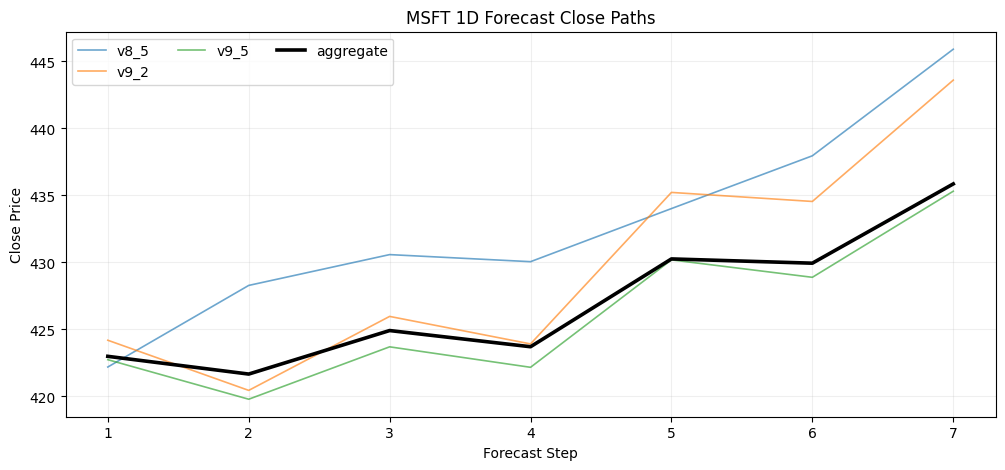

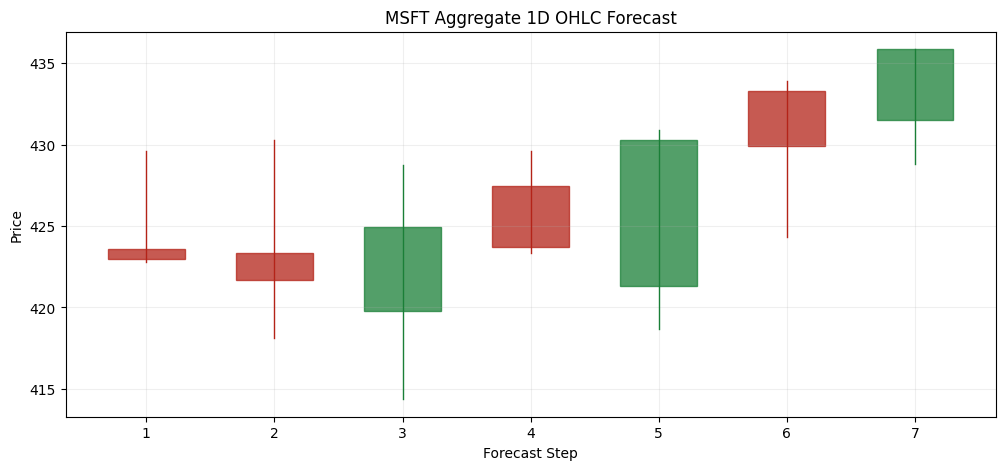

In [14]:
def plot_aggregate_candles(path: np.ndarray, title: str) -> None:
    fig, ax = plt.subplots(figsize=(12, 5))
    for idx, candle in enumerate(path, start=1):
        open_price, high_price, low_price, close_price = candle
        color = "#1a7f37" if close_price >= open_price else "#b42318"
        ax.plot([idx, idx], [low_price, high_price], color=color, linewidth=1.0)
        body_low = min(open_price, close_price)
        body_high = max(open_price, close_price)
        body_height = max(body_high - body_low, 1e-6)
        rect = Rectangle((idx - 0.3, body_low), 0.6, body_height, facecolor=color, edgecolor=color, alpha=0.75)
        ax.add_patch(rect)
    ax.set_title(title)
    ax.set_xlabel("Forecast Step")
    ax.set_ylabel("Price")
    ax.grid(alpha=0.2)
    plt.show()


plt.figure(figsize=(12, 5))
for expert_name in EXPECTED_EXPERTS:
    plt.plot(close_path_df["step"], close_path_df[expert_name], linewidth=1.2, alpha=0.65, label=expert_name)
plt.plot(close_path_df["step"], close_path_df["aggregate_close"], linewidth=2.6, color="black", label="aggregate")
plt.title(f"{SYMBOL} 1D Forecast Close Paths")
plt.xlabel("Forecast Step")
plt.ylabel("Close Price")
plt.grid(alpha=0.2)
plt.legend(ncol=3)
plt.show()

plot_aggregate_candles(aggregate_path, f"{SYMBOL} Aggregate 1D OHLC Forecast")


## Daily Rolling Backtest

This section replays a strictly causal rolling daily window using the frozen expert artifacts. For each anchor day, every expert predicts from its own feature block, the saved ensemble weights form the aggregate OHLC path, and the individual expert paths are shown as close-line overlays.


In [15]:
FINAL_ROLLING_FRAME_OUTPUT_DIR = FINAL_RUN_DIR / "rolling_frames"
MAX_ROLLING_LOOKBACK = max(int(MODEL_ARTIFACTS[expert_name]["lookback"]) for expert_name in EXPECTED_EXPERTS)

print(
    {
        "final_rolling_window": FINAL_ROLLING_WINDOW,
        "final_rolling_step": FINAL_ROLLING_STEP,
        "final_rolling_backtest_date": FINAL_ROLLING_BACKTEST_DATE,
        "final_rolling_history_bars": FINAL_ROLLING_HISTORY_BARS,
        "final_rolling_save_frames": FINAL_ROLLING_SAVE_FRAMES,
        "final_rolling_device": str(FINAL_ROLLING_DEVICE),
        "final_rolling_clear_every": FINAL_ROLLING_CLEAR_EVERY,
        "max_rolling_lookback": MAX_ROLLING_LOOKBACK,
    }
)


{'final_rolling_window': 60, 'final_rolling_step': 1, 'final_rolling_backtest_date': None, 'final_rolling_history_bars': 180, 'final_rolling_save_frames': False, 'final_rolling_device': 'cpu', 'final_rolling_clear_every': 24, 'max_rolling_lookback': 256}


In [16]:
@dataclass
class FinalRollingLog:
    anchor_index: int
    anchor_timestamp: pd.Timestamp
    future_timestamps: List[pd.Timestamp]
    anchor_prev_close: float
    actual_path: np.ndarray
    aggregate_path: np.ndarray
    expert_paths: Dict[str, np.ndarray]
    aggregate_regime_indicator: float
    aggregate_soft_swing_cap: Optional[float]
    aggregate_t1_temporal_cap: Optional[float]
    aggregate_t1_direction_vote: float
    aggregate_t1_momentum_sign: float
    temperatures: Dict[str, float]


def rolling_metric_steps() -> List[int]:
    return sorted({1, min(3, HORIZON), min(5, HORIZON), HORIZON})


def select_final_rolling_backtest_date(session_df: pd.DataFrame, requested: Optional[str], max_lookback: int, horizon: int) -> str:
    last_anchor = len(session_df) - horizon
    if last_anchor <= max_lookback:
        raise RuntimeError("Not enough rows for a daily rolling backtest.")

    if requested is not None:
        requested_positions = np.where(session_df["session_date"].to_numpy() == requested)[0]
        if len(requested_positions) == 0:
            raise ValueError(f"Requested backtest start date not found: {requested}")
        first_anchor = int(requested_positions[0])
        if first_anchor < max_lookback:
            raise ValueError(f"Backtest start date {requested} does not have enough prior bars for lookback={max_lookback}.")
        if first_anchor > last_anchor:
            raise ValueError(f"Backtest start date {requested} leaves no room for horizon={horizon}.")
        return requested

    first_anchor = max(max_lookback, last_anchor - FINAL_ROLLING_WINDOW + 1)
    return pd.Timestamp(session_df["timestamp"].iloc[first_anchor]).tz_convert(SESSION_TZ).strftime("%Y-%m-%d")


def build_final_rolling_anchor_indices(session_df: pd.DataFrame, backtest_date: str, max_lookback: int, horizon: int, step: int) -> np.ndarray:
    positions = np.where(session_df["session_date"].to_numpy() >= backtest_date)[0]
    if len(positions) == 0:
        raise RuntimeError(f"No daily positions found for {backtest_date}")
    first_anchor = max(int(positions[0]), max_lookback)
    last_anchor = len(session_df) - horizon
    if first_anchor > last_anchor:
        raise RuntimeError(f"No valid daily rolling anchors for {backtest_date}")
    return np.arange(first_anchor, last_anchor + 1, step, dtype=np.int32)


def build_actual_paths_for_anchor_indices(feature_df: pd.DataFrame, anchor_indices: np.ndarray) -> Dict[str, Any]:
    timestamps: List[pd.Timestamp] = []
    future_timestamps: List[List[pd.Timestamp]] = []
    prev_close: List[float] = []
    actual_paths: List[np.ndarray] = []

    for anchor_index in anchor_indices:
        timestamps.append(pd.Timestamp(feature_df["timestamp"].iloc[anchor_index]))
        prev_close_value = float(feature_df["prev_close"].iloc[anchor_index])
        prev_close.append(prev_close_value)
        future_slice = feature_df.iloc[anchor_index : anchor_index + HORIZON]
        future_timestamps.append([pd.Timestamp(ts) for ts in future_slice["timestamp"].tolist()])
        actual_returns = future_slice.loc[:, TARGET_COLUMNS].to_numpy(dtype=np.float32)
        actual_paths.append(returns_to_prices_seq(prev_close_value, actual_returns))

    return {
        "anchor_timestamps": timestamps,
        "future_timestamps": future_timestamps,
        "prev_close": np.asarray(prev_close, dtype=np.float32),
        "actual_paths": np.stack(actual_paths).astype(np.float32),
    }


def run_final_rolling_for_bundle(expert_name: str, anchor_indices: np.ndarray) -> Dict[str, Any]:
    bundle = load_expert_bundle(expert_name, device_override=FINAL_ROLLING_DEVICE)
    feature_df = FEATURE_FRAMES[bundle.feature_mode]
    predicted_paths: List[np.ndarray] = []
    regime_indicators: List[float] = []
    temperatures: List[float] = []

    for offset, anchor_index in enumerate(tqdm(anchor_indices, desc=f"{bundle.version} final rolling")):
        model_input = build_anchor_input(feature_df, bundle, int(anchor_index))
        regime_indicator = 0.0
        regime_multiplier = 1.0
        if bundle.feature_mode == "regime":
            recent_history = feature_df.iloc[max(0, int(anchor_index) - FINAL_AGGREGATE_GUARD_LOOKBACK) : int(anchor_index)].copy()
            _, regime_multiplier, regime_indicator = detect_regime_multiplier(recent_history)

        base_temperature = float(bundle.inference_config["sampling_temperature"])
        effective_temperature = base_temperature

        predicted_path = generate_ensemble_with_trend_selection(
            bundle=bundle,
            model_input=model_input,
            temperature=effective_temperature,
            regime_multiplier=regime_multiplier,
        )

        predicted_paths.append(predicted_path)
        regime_indicators.append(float(regime_indicator))
        temperatures.append(float(effective_temperature * regime_multiplier))

        if (offset + 1) % FINAL_ROLLING_CLEAR_EVERY == 0:
            clear_torch_memory()

    result = {
        "expert": expert_name,
        "version": bundle.version,
        "lookback": bundle.lookback,
        "feature_mode": bundle.feature_mode,
        "architecture": bundle.architecture,
        "predicted_paths": np.stack(predicted_paths).astype(np.float32),
        "regime_indicators": np.asarray(regime_indicators, dtype=np.float32),
        "temperatures": np.asarray(temperatures, dtype=np.float32),
    }

    bundle.model = bundle.model.to("cpu")
    del bundle.model
    clear_torch_memory()
    return result


def build_final_rolling_logs(
    anchor_indices: np.ndarray,
    actual_payload: Dict[str, Any],
    expert_outputs: Dict[str, Dict[str, Any]],
) -> List[FinalRollingLog]:
    logs: List[FinalRollingLog] = []
    previous_aggregate_next_close: Optional[float] = None
    for offset, anchor_index in enumerate(anchor_indices):
        aggregate_raw = np.zeros((HORIZON, 4), dtype=np.float32)
        aggregate_regime_indicator = 0.0
        expert_paths: Dict[str, np.ndarray] = {}
        temperatures: Dict[str, float] = {}
        for expert_name in EXPECTED_EXPERTS:
            expert_path = expert_outputs[expert_name]["predicted_paths"][offset]
            expert_paths[expert_name] = expert_path
            temperatures[expert_name] = float(expert_outputs[expert_name]["temperatures"][offset])
            aggregate_raw += float(ensemble_weights[expert_name]) * expert_path
            aggregate_regime_indicator += float(ensemble_weights[expert_name]) * float(expert_outputs[expert_name]["regime_indicators"][offset])
        aggregate_guard_history = build_guard_history_slice(FEATURE_FRAMES["technical"], int(anchor_index), FINAL_AGGREGATE_GUARD_LOOKBACK)
        aggregate_path, aggregate_soft_swing_cap = postprocess_aggregate_path(
            aggregate_raw,
            float(actual_payload["prev_close"][offset]),
            aggregate_guard_history,
        )
        aggregate_path, aggregate_t1_temporal_cap, aggregate_t1_direction_vote, aggregate_t1_momentum_sign = apply_t1_temporal_direction_guard(
            aggregate_path,
            float(actual_payload["prev_close"][offset]),
            aggregate_guard_history,
            expert_paths,
            ensemble_weights,
            previous_next_close=previous_aggregate_next_close,
        )
        previous_aggregate_next_close = float(aggregate_path[0, 3])

        logs.append(
            FinalRollingLog(
                anchor_index=int(anchor_index),
                anchor_timestamp=actual_payload["anchor_timestamps"][offset],
                future_timestamps=actual_payload["future_timestamps"][offset],
                anchor_prev_close=float(actual_payload["prev_close"][offset]),
                actual_path=actual_payload["actual_paths"][offset],
                aggregate_path=aggregate_path,
                expert_paths=expert_paths,
                aggregate_regime_indicator=float(aggregate_regime_indicator),
                aggregate_soft_swing_cap=aggregate_soft_swing_cap,
                aggregate_t1_temporal_cap=aggregate_t1_temporal_cap,
                aggregate_t1_direction_vote=float(aggregate_t1_direction_vote),
                aggregate_t1_momentum_sign=float(aggregate_t1_momentum_sign),
                temperatures=temperatures,
            )
        )
    return logs


def summarize_final_rolling_logs(logs: List[FinalRollingLog]) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    summary_rows: List[Dict[str, Any]] = []
    next_close_rows: List[Dict[str, Any]] = []
    metric_steps = rolling_metric_steps()

    for log in logs:
        pred_close = log.aggregate_path[:, 3]
        actual_close = log.actual_path[:, 3]
        direction_hit = bool(np.sign(pred_close[0] - log.anchor_prev_close) == np.sign(actual_close[0] - log.anchor_prev_close))
        row = {
            "anchor_timestamp": log.anchor_timestamp,
            "anchor_prev_close": log.anchor_prev_close,
            "aggregate_regime_indicator": float(log.aggregate_regime_indicator),
            "aggregate_regime_name": regime_name_from_indicator(log.aggregate_regime_indicator),
            "aggregate_soft_swing_cap": float(log.aggregate_soft_swing_cap) if log.aggregate_soft_swing_cap is not None else np.nan,
            "aggregate_t1_temporal_cap": float(log.aggregate_t1_temporal_cap) if log.aggregate_t1_temporal_cap is not None else np.nan,
            "aggregate_t1_direction_vote": float(log.aggregate_t1_direction_vote),
            "aggregate_t1_momentum_sign": float(log.aggregate_t1_momentum_sign),
            "direction_hit": float(direction_hit),
            "path_mae": float(np.mean(np.abs(pred_close - actual_close))),
        }
        for step in metric_steps:
            row[f"step_{step}_close_mae"] = float(abs(pred_close[step - 1] - actual_close[step - 1]))
        summary_rows.append(row)

        next_close_row = {
            "anchor_timestamp": log.anchor_timestamp,
            "actual_next_close": float(actual_close[0]),
            "aggregate_next_close": float(pred_close[0]),
        }
        for expert_name, expert_path in log.expert_paths.items():
            next_close_row[f"{expert_name}_next_close"] = float(expert_path[0, 3])
        next_close_rows.append(next_close_row)

    summary_df = pd.DataFrame(summary_rows)
    next_close_df = pd.DataFrame(next_close_rows)
    metrics_rows = [
        {"metric": "prediction_count", "value": int(len(summary_df))},
        {"metric": "directional_hit_rate_t1", "value": float(summary_df["direction_hit"].mean())},
        {"metric": "aggregate_path_mae", "value": float(summary_df["path_mae"].mean())},
    ]
    for step in metric_steps:
        metrics_rows.append({"metric": f"aggregate_step_{step}_close_mae", "value": float(summary_df[f"step_{step}_close_mae"].mean())})
    metrics_df = pd.DataFrame(metrics_rows)
    return summary_df, metrics_df, next_close_df


def _rolling_candle_frame(ohlc_values: np.ndarray, timestamps: Sequence[pd.Timestamp]) -> pd.DataFrame:
    return pd.DataFrame(ohlc_values, columns=["Open", "High", "Low", "Close"], index=pd.Index(timestamps))


def _draw_rolling_candles(
    ax,
    ohlc_df: pd.DataFrame,
    start_x: int,
    up_edge: str,
    up_face: str,
    down_edge: str,
    down_face: str,
    wick_color: str,
    width: float = 0.58,
    lw: float = 1.0,
    alpha: float = 1.0,
    zorder: int = 3,
) -> None:
    values = ohlc_df[["Open", "High", "Low", "Close"]].to_numpy(dtype=np.float32)
    for idx, (open_price, high_price, low_price, close_price) in enumerate(values):
        x_value = start_x + idx
        bull = close_price >= open_price
        ax.vlines(x_value, low_price, high_price, color=wick_color, linewidth=lw, alpha=alpha, zorder=zorder - 1)
        body_low = min(open_price, close_price)
        body_height = max(abs(close_price - open_price), 1e-6)
        rect = Rectangle(
            (x_value - width / 2, body_low),
            width,
            body_height,
            facecolor=up_face if bull else down_face,
            edgecolor=up_edge if bull else down_edge,
            linewidth=lw,
            alpha=alpha,
            zorder=zorder,
        )
        ax.add_patch(rect)


def render_final_rolling_frame(log: FinalRollingLog, pricedf: pd.DataFrame, history_bars: int = FINAL_ROLLING_HISTORY_BARS) -> plt.Figure:
    history_start = max(0, log.anchor_index - history_bars)
    history_df = pricedf.iloc[history_start : log.anchor_index][["timestamp", "open", "high", "low", "close"]].copy()
    history_ohlc = history_df.rename(columns={"open": "Open", "high": "High", "low": "Low", "close": "Close"}).set_index("timestamp")
    actual_ohlc = _rolling_candle_frame(log.actual_path, log.future_timestamps)
    aggregate_ohlc = _rolling_candle_frame(log.aggregate_path, log.future_timestamps)

    fig, ax = plt.subplots(figsize=(18, 8), facecolor="black")
    FigureCanvasAgg(fig)
    ax.set_facecolor("black")

    _draw_rolling_candles(
        ax,
        history_ohlc,
        0,
        up_edge="#00FF00",
        up_face="#00FF00",
        down_edge="#FF0000",
        down_face="#FF0000",
        wick_color="#D0D0D0",
        width=0.60,
        lw=1.0,
        alpha=0.95,
        zorder=3,
    )

    future_start_x = len(history_ohlc)
    _draw_rolling_candles(
        ax,
        actual_ohlc,
        future_start_x,
        up_edge="#1D6F42",
        up_face="#1D6F42",
        down_edge="#8E2F25",
        down_face="#8E2F25",
        wick_color="#8E8E8E",
        width=0.58,
        lw=0.9,
        alpha=0.40,
        zorder=2,
    )
    _draw_rolling_candles(
        ax,
        aggregate_ohlc,
        future_start_x,
        up_edge="#FFFFFF",
        up_face="#FFFFFF",
        down_edge="#FFFFFF",
        down_face="#000000",
        wick_color="#F3F3F3",
        width=0.50,
        lw=1.2,
        alpha=1.0,
        zorder=4,
    )

    color_map = plt.cm.tab10(np.linspace(0, 1, max(len(log.expert_paths), 1)))
    line_handles = []
    for idx, expert_name in enumerate(EXPECTED_EXPERTS):
        expert_path = log.expert_paths[expert_name]
        close_values = expert_path[:, 3]
        x_values = np.arange(len(close_values)) + future_start_x
        handle, = ax.plot(
            x_values,
            close_values,
            color=color_map[idx % len(color_map)],
            linewidth=1.15,
            alpha=0.85,
            zorder=5,
            label=expert_name,
        )
        line_handles.append(handle)

    now_x = len(history_ohlc) - 0.5
    ax.axvline(now_x, color="white", linestyle="--", linewidth=1.0, alpha=0.85, zorder=6)

    full_index = history_ohlc.index.append(actual_ohlc.index)
    tick_step = max(1, len(full_index) // 10)
    ticks = list(range(0, len(full_index), tick_step))
    if ticks[-1] != len(full_index) - 1:
        ticks.append(len(full_index) - 1)
    labels = [pd.Timestamp(full_index[i]).tz_convert(SESSION_TZ).strftime("%Y-%m-%d") for i in ticks]

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, rotation=25, ha="right", color="white", fontsize=9)
    ax.tick_params(axis="y", colors="white")
    for spine in ax.spines.values():
        spine.set_color("#666666")
    ax.grid(color="#242424", linewidth=0.6, alpha=0.35)

    header = (
        f"{SYMBOL} 1D Final Rolling | Anchor: {log.anchor_timestamp.tz_convert(SESSION_TZ).strftime('%Y-%m-%d')} | "
        f"Regime: {regime_name_from_indicator(log.aggregate_regime_indicator)}"
    )
    ax.set_title(header, color="white", pad=12)
    ax.set_ylabel("Price", color="white")

    legend_handles = [
        Patch(facecolor="#00FF00", edgecolor="#00FF00", label="History (bull)"),
        Patch(facecolor="#FF0000", edgecolor="#FF0000", label="History (bear)"),
        Patch(facecolor="#1D6F42", edgecolor="#1D6F42", label="Actual Future (dim bull)"),
        Patch(facecolor="#8E2F25", edgecolor="#8E2F25", label="Actual Future (dim bear)"),
        Patch(facecolor="#FFFFFF", edgecolor="#FFFFFF", label="Aggregate (bull)"),
        Patch(facecolor="#000000", edgecolor="#FFFFFF", label="Aggregate (bear)"),
    ] + line_handles
    legend = ax.legend(handles=legend_handles, facecolor="black", edgecolor="#666666", loc="upper left", ncol=2)
    for text in legend.get_texts():
        text.set_color("white")

    plt.tight_layout()
    return fig


def generate_final_rolling_frames(logs: List[FinalRollingLog], pricedf: pd.DataFrame, output_dir: Path) -> List[Path]:
    output_dir.mkdir(parents=True, exist_ok=True)
    saved_paths: List[Path] = []
    for idx, log in enumerate(tqdm(logs, desc="Saving final rolling frames")):
        fig = render_final_rolling_frame(log, pricedf, history_bars=FINAL_ROLLING_HISTORY_BARS)
        output_path = output_dir / f"frame_{idx:04d}.png"
        fig.savefig(output_path, dpi=180, facecolor="black", bbox_inches="tight")
        saved_paths.append(output_path)
        plt.close(fig)
    return saved_paths


C:\Users\Arya\AppData\Local\Temp\ipykernel_26396\752046132.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location="cpu")
v8.5 

{'rolling_backtest_start_date': '2026-01-16', 'rolling_prediction_count': 60, 'first_anchor': '2026-01-16 05:00:00+00:00', 'last_anchor': '2026-04-14 04:00:00+00:00'}


,metric,value
0,prediction_count,60.000000
1,directional_hit_rate_t1,0.516667
2,aggregate_path_mae,15.392645
3,aggregate_step_1_close_mae,7.225315
4,aggregate_step_3_close_mae,13.493292
5,aggregate_step_5_close_mae,18.125271
6,aggregate_step_7_close_mae,21.679152


,anchor_timestamp,anchor_prev_close,aggregate_regime_indicator,aggregate_regime_name,aggregate_soft_swing_cap,aggregate_t1_temporal_cap,aggregate_t1_direction_vote,aggregate_t1_momentum_sign,direction_hit,path_mae,step_1_close_mae,step_3_close_mae,step_5_close_mae,step_7_close_mae
0,2026-01-16 05:00:00+00:00,456.709991,0.000000,NORMAL,17.223637,15.3099,0.783195,-1.0,1.0,11.463213,0.439911,16.011963,12.438660,26.757477
1,2026-01-20 05:00:00+00:00,459.760010,0.000000,NORMAL,17.223637,15.3099,0.783195,-1.0,0.0,15.597251,6.609711,9.414581,16.029083,27.438080
2,2026-01-21 05:00:00+00:00,454.635010,0.000000,NORMAL,17.223637,15.3099,0.455826,-1.0,1.0,18.365400,10.368439,10.659637,33.747528,13.863525
3,2026-01-22 05:00:00+00:00,444.000000,0.054201,NORMAL,17.223637,15.3099,0.455826,-1.0,1.0,21.306484,6.240631,23.789795,43.777313,8.224457
4,2026-01-23 05:00:00+00:00,450.915009,0.054201,NORMAL,17.223637,15.3099,0.455826,-1.0,1.0,21.006069,14.050964,28.763733,11.179962,21.996063


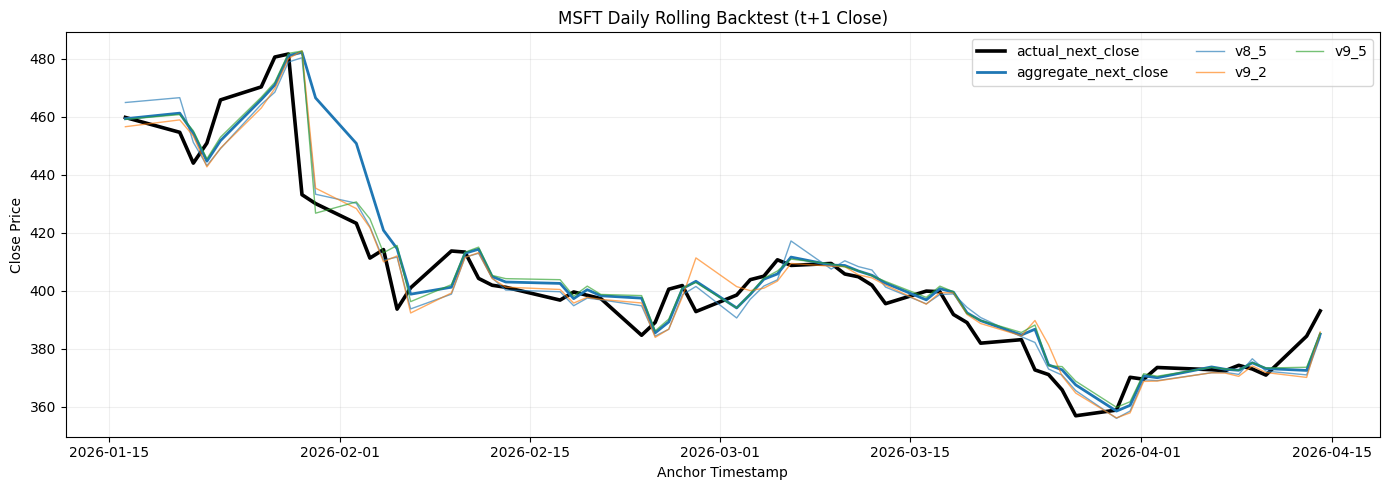

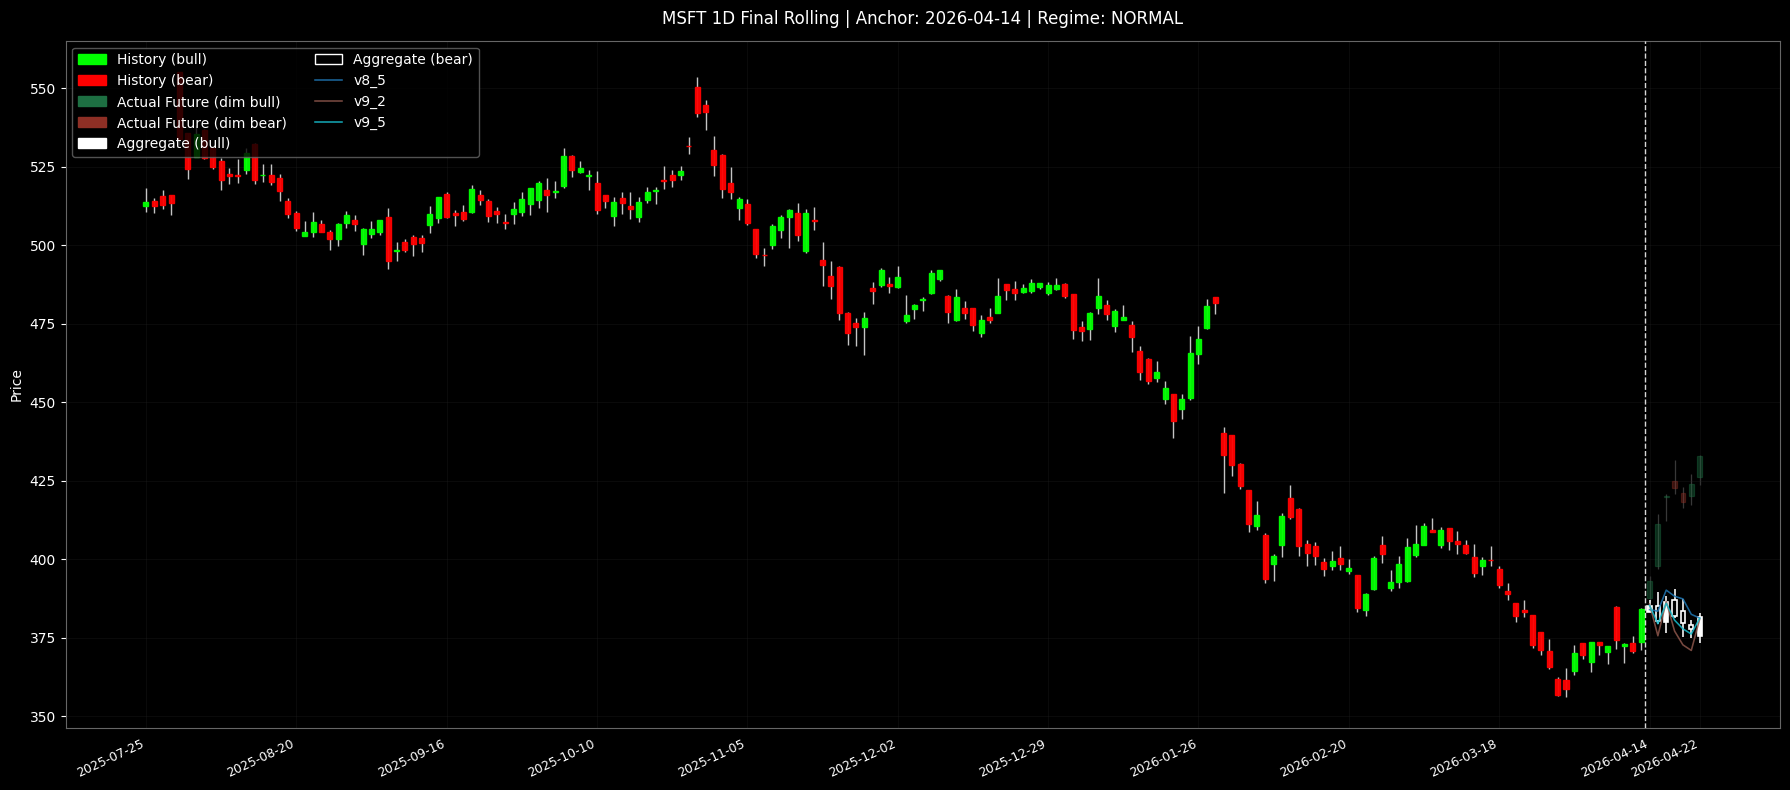

In [17]:
FINAL_ROLLING_BACKTEST_DATE = select_final_rolling_backtest_date(
    session_df=session_df,
    requested=FINAL_ROLLING_BACKTEST_DATE,
    max_lookback=MAX_ROLLING_LOOKBACK,
    horizon=HORIZON,
)
FINAL_ROLLING_ANCHOR_INDICES = build_final_rolling_anchor_indices(
    session_df=session_df,
    backtest_date=FINAL_ROLLING_BACKTEST_DATE,
    max_lookback=MAX_ROLLING_LOOKBACK,
    horizon=HORIZON,
    step=FINAL_ROLLING_STEP,
)

FINAL_ROLLING_ACTUAL = build_actual_paths_for_anchor_indices(FEATURE_FRAMES["core"], FINAL_ROLLING_ANCHOR_INDICES)

FINAL_ROLLING_EXPERT_OUTPUTS: Dict[str, Dict[str, Any]] = {}
for expert_name in EXPECTED_EXPERTS:
    FINAL_ROLLING_EXPERT_OUTPUTS[expert_name] = run_final_rolling_for_bundle(expert_name, FINAL_ROLLING_ANCHOR_INDICES)

FINAL_ROLLING_LOGS = build_final_rolling_logs(
    anchor_indices=FINAL_ROLLING_ANCHOR_INDICES,
    actual_payload=FINAL_ROLLING_ACTUAL,
    expert_outputs=FINAL_ROLLING_EXPERT_OUTPUTS,
)

FINAL_ROLLING_SUMMARY_DF, FINAL_ROLLING_METRICS_DF, FINAL_ROLLING_NEXT_CLOSE_DF = summarize_final_rolling_logs(FINAL_ROLLING_LOGS)

print(
    {
        "rolling_backtest_start_date": FINAL_ROLLING_BACKTEST_DATE,
        "rolling_prediction_count": len(FINAL_ROLLING_LOGS),
        "first_anchor": str(FINAL_ROLLING_LOGS[0].anchor_timestamp),
        "last_anchor": str(FINAL_ROLLING_LOGS[-1].anchor_timestamp),
    }
)
display(FINAL_ROLLING_METRICS_DF)
display(FINAL_ROLLING_SUMMARY_DF.head())

plt.figure(figsize=(14, 5))
plt.plot(FINAL_ROLLING_NEXT_CLOSE_DF["anchor_timestamp"], FINAL_ROLLING_NEXT_CLOSE_DF["actual_next_close"], color="black", linewidth=2.6, label="actual_next_close")
plt.plot(FINAL_ROLLING_NEXT_CLOSE_DF["anchor_timestamp"], FINAL_ROLLING_NEXT_CLOSE_DF["aggregate_next_close"], color="#1f77b4", linewidth=2.0, label="aggregate_next_close")
for expert_name in EXPECTED_EXPERTS:
    plt.plot(
        FINAL_ROLLING_NEXT_CLOSE_DF["anchor_timestamp"],
        FINAL_ROLLING_NEXT_CLOSE_DF[f"{expert_name}_next_close"],
        linewidth=1.0,
        alpha=0.65,
        label=expert_name,
    )
plt.title(f"{SYMBOL} Daily Rolling Backtest (t+1 Close)")
plt.xlabel("Anchor Timestamp")
plt.ylabel("Close Price")
plt.grid(alpha=0.2)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

preview_index = FINAL_ROLLING_DISPLAY_FRAME_INDEX if FINAL_ROLLING_DISPLAY_FRAME_INDEX >= 0 else len(FINAL_ROLLING_LOGS) - 1
preview_index = max(0, min(preview_index, len(FINAL_ROLLING_LOGS) - 1))
FINAL_ROLLING_PREVIEW_FIG = render_final_rolling_frame(
    FINAL_ROLLING_LOGS[preview_index],
    pricedf=session_df,
    history_bars=FINAL_ROLLING_HISTORY_BARS,
)
plt.show()

FINAL_ROLLING_SAVED_FRAMES: List[Path] = []
if FINAL_ROLLING_SAVE_FRAMES:
    FINAL_ROLLING_SAVED_FRAMES = generate_final_rolling_frames(
        logs=FINAL_ROLLING_LOGS,
        pricedf=session_df,
        output_dir=FINAL_ROLLING_FRAME_OUTPUT_DIR,
    )
    print(
        {
            "rolling_frames_dir": str(FINAL_ROLLING_FRAME_OUTPUT_DIR),
            "rolling_frames_saved": len(FINAL_ROLLING_SAVED_FRAMES),
        }
    )


In [18]:
if SAVE_RUN_OUTPUTS:
    ensure_dir(FINAL_RUN_DIR)
    save_dataframe(artifact_summary_df, FINAL_RUN_DIR / "expert_artifact_summary.csv")
    save_dataframe(expert_summary_df, FINAL_RUN_DIR / "expert_prediction_summary.csv")
    save_dataframe(close_path_df, FINAL_RUN_DIR / "close_path_comparison.csv")
    save_dataframe(pd.DataFrame(aggregate_path, columns=["Open", "High", "Low", "Close"]), FINAL_RUN_DIR / "aggregate_forecast.csv")
    save_dataframe(FINAL_ROLLING_SUMMARY_DF, FINAL_RUN_DIR / "rolling_backtest_summary.csv")
    save_dataframe(FINAL_ROLLING_METRICS_DF, FINAL_RUN_DIR / "rolling_backtest_metrics.csv")
    save_dataframe(FINAL_ROLLING_NEXT_CLOSE_DF, FINAL_RUN_DIR / "rolling_backtest_next_close.csv")
    FINAL_ROLLING_PREVIEW_FIG.savefig(FINAL_RUN_DIR / "rolling_backtest_preview.png", dpi=180, facecolor="black", bbox_inches="tight")
    save_json(
        FINAL_RUN_DIR / "policy_summary.json",
        {
            "summary": policy_summary_df.iloc[0].to_dict(),
            "portfolio_state": PORTFOLIO_STATE,
            "run_label": RUN_LABEL,
            "symbol": SYMBOL,
            "excluded_experts": sorted(FINAL_EXCLUDED_EXPERTS),
            "saved_weights": saved_ensemble_weights,
            "final_weights": ensemble_weights,
            "aggregate_shrink": FINAL_AGGREGATE_SHRINK,
            "soft_swing_guard": {
                "enabled": FINAL_SOFT_SWING_GUARD_ENABLED,
                "lookback": FINAL_SOFT_SWING_GUARD_LOOKBACK,
                "q95_mult": FINAL_SOFT_SWING_GUARD_Q95_MULT,
                "atr_mult": FINAL_SOFT_SWING_GUARD_ATR_MULT,
                "min_move": FINAL_SOFT_SWING_GUARD_MIN_MOVE,
                "excess_scale": FINAL_SOFT_SWING_GUARD_EXCESS_SCALE,
                "hard_mult": FINAL_SOFT_SWING_GUARD_HARD_MULT,
                "extreme_scale": FINAL_SOFT_SWING_GUARD_EXTREME_SCALE,
                "latest_cap": aggregate_soft_swing_cap,
            },
            "empirical_envelope": {
                "enabled": FINAL_EMPIRICAL_ENVELOPE_ENABLED,
                "lookback": FINAL_EMPIRICAL_ENVELOPE_LOOKBACK,
                "q95_mult": FINAL_EMPIRICAL_ENVELOPE_Q95_MULT,
                "step_base_mult": FINAL_EMPIRICAL_ENVELOPE_STEP_BASE_MULT,
                "atr_mult": FINAL_EMPIRICAL_ENVELOPE_ATR_MULT,
                "min_move": FINAL_EMPIRICAL_ENVELOPE_MIN_MOVE,
                "excess_scale": FINAL_EMPIRICAL_ENVELOPE_EXCESS_SCALE,
                "hard_mult": FINAL_EMPIRICAL_ENVELOPE_HARD_MULT,
                "extreme_scale": FINAL_EMPIRICAL_ENVELOPE_EXTREME_SCALE,
            },
            "candle_range_guard": {
                "enabled": FINAL_CANDLE_RANGE_GUARD_ENABLED,
                "lookback": FINAL_CANDLE_RANGE_GUARD_LOOKBACK,
                "q97_mult": FINAL_CANDLE_RANGE_GUARD_Q97_MULT,
                "min_wick": FINAL_CANDLE_RANGE_GUARD_MIN_WICK,
            },
            "t1_temporal_guard": {
                "enabled": FINAL_T1_TEMPORAL_GUARD_ENABLED,
                "lookback": FINAL_T1_TEMPORAL_GUARD_LOOKBACK,
                "q95_mult": FINAL_T1_TEMPORAL_Q95_MULT,
                "atr_mult": FINAL_T1_TEMPORAL_ATR_MULT,
                "min_move": FINAL_T1_TEMPORAL_MIN_MOVE,
                "excess_scale": FINAL_T1_TEMPORAL_EXCESS_SCALE,
                "hard_mult": FINAL_T1_TEMPORAL_HARD_MULT,
                "extreme_scale": FINAL_T1_TEMPORAL_EXTREME_SCALE,
                "recap_excess_scale": FINAL_T1_TEMPORAL_RECAP_EXCESS_SCALE,
                "recap_hard_mult": FINAL_T1_TEMPORAL_RECAP_HARD_MULT,
                "recap_extreme_scale": FINAL_T1_TEMPORAL_RECAP_EXTREME_SCALE,
                "latest_cap": aggregate_t1_temporal_cap,
                "previous_next_close_ref": previous_aggregate_next_close,
            },
            "t1_direction_guard": {
                "enabled": FINAL_T1_DIRECTION_GUARD_ENABLED,
                "vote_threshold": FINAL_T1_DIRECTION_VOTE_THRESHOLD,
                "momentum_bars": FINAL_T1_DIRECTION_MOMENTUM_BARS,
                "momentum_min_move": FINAL_T1_DIRECTION_MOMENTUM_MIN_MOVE,
                "max_abs_delta_to_override": FINAL_T1_DIRECTION_MAX_ABS_DELTA_TO_OVERRIDE,
                "min_override_move": FINAL_T1_DIRECTION_MIN_OVERRIDE_MOVE,
                "max_override_move": FINAL_T1_DIRECTION_MAX_OVERRIDE_MOVE,
                "shift_fade_power": FINAL_T1_SHIFT_FADE_POWER,
                "latest_vote": aggregate_t1_direction_vote,
                "latest_momentum_sign": aggregate_t1_momentum_sign,
            },
        },
    )
    save_npz(
        FINAL_RUN_DIR / "forecast_bundle.npz",
        aggregate_path=aggregate_path.astype(np.float32),
        aggregate_path_raw=aggregate_path_raw.astype(np.float32),
        aggregate_regime_indicator=np.asarray([aggregate_regime_indicator], dtype=np.float32),
        close_path_steps=close_path_df["step"].to_numpy(dtype=np.int32),
        close_path_values=close_path_df.drop(columns=["step"]).to_numpy(dtype=np.float32),
    )
    rolling_bundle_arrays = {
        "anchor_indices": FINAL_ROLLING_ANCHOR_INDICES.astype(np.int32),
        "anchor_timestamps": np.asarray([ts.isoformat() for ts in FINAL_ROLLING_ACTUAL["anchor_timestamps"]]),
        "prev_close": FINAL_ROLLING_ACTUAL["prev_close"].astype(np.float32),
        "actual_paths": FINAL_ROLLING_ACTUAL["actual_paths"].astype(np.float32),
        "aggregate_paths": np.stack([log.aggregate_path for log in FINAL_ROLLING_LOGS]).astype(np.float32),
    }
    for expert_name in EXPECTED_EXPERTS:
        rolling_bundle_arrays[f"{expert_name}_predicted_paths"] = FINAL_ROLLING_EXPERT_OUTPUTS[expert_name]["predicted_paths"].astype(np.float32)
        rolling_bundle_arrays[f"{expert_name}_temperatures"] = FINAL_ROLLING_EXPERT_OUTPUTS[expert_name]["temperatures"].astype(np.float32)
    save_npz(FINAL_RUN_DIR / "rolling_backtest_bundle.npz", **rolling_bundle_arrays)
    save_json(
        FINAL_RUN_DIR / "run_metadata.json",
        {
            "created_at_utc": production_timestamp_utc(),
            "symbol": SYMBOL,
            "anchor_timestamp": str(list(EXPERT_PREDICTIONS.values())[0]["anchor_timestamp"]),
            "manifest_path": str(MANIFEST_PATH),
            "weights_path": str(weights_path),
            "policy_path": str(policy_path),
            "excluded_experts": sorted(FINAL_EXCLUDED_EXPERTS),
            "saved_weights": saved_ensemble_weights,
            "final_weights": ensemble_weights,
            "aggregate_shrink": FINAL_AGGREGATE_SHRINK,
            "soft_swing_guard": {
                "enabled": FINAL_SOFT_SWING_GUARD_ENABLED,
                "lookback": FINAL_SOFT_SWING_GUARD_LOOKBACK,
                "q95_mult": FINAL_SOFT_SWING_GUARD_Q95_MULT,
                "atr_mult": FINAL_SOFT_SWING_GUARD_ATR_MULT,
                "min_move": FINAL_SOFT_SWING_GUARD_MIN_MOVE,
                "excess_scale": FINAL_SOFT_SWING_GUARD_EXCESS_SCALE,
                "hard_mult": FINAL_SOFT_SWING_GUARD_HARD_MULT,
                "extreme_scale": FINAL_SOFT_SWING_GUARD_EXTREME_SCALE,
                "latest_cap": aggregate_soft_swing_cap,
            },
            "empirical_envelope": {
                "enabled": FINAL_EMPIRICAL_ENVELOPE_ENABLED,
                "lookback": FINAL_EMPIRICAL_ENVELOPE_LOOKBACK,
                "q95_mult": FINAL_EMPIRICAL_ENVELOPE_Q95_MULT,
                "step_base_mult": FINAL_EMPIRICAL_ENVELOPE_STEP_BASE_MULT,
                "atr_mult": FINAL_EMPIRICAL_ENVELOPE_ATR_MULT,
                "min_move": FINAL_EMPIRICAL_ENVELOPE_MIN_MOVE,
                "excess_scale": FINAL_EMPIRICAL_ENVELOPE_EXCESS_SCALE,
                "hard_mult": FINAL_EMPIRICAL_ENVELOPE_HARD_MULT,
                "extreme_scale": FINAL_EMPIRICAL_ENVELOPE_EXTREME_SCALE,
            },
            "candle_range_guard": {
                "enabled": FINAL_CANDLE_RANGE_GUARD_ENABLED,
                "lookback": FINAL_CANDLE_RANGE_GUARD_LOOKBACK,
                "q97_mult": FINAL_CANDLE_RANGE_GUARD_Q97_MULT,
                "min_wick": FINAL_CANDLE_RANGE_GUARD_MIN_WICK,
            },
            "t1_temporal_guard": {
                "enabled": FINAL_T1_TEMPORAL_GUARD_ENABLED,
                "lookback": FINAL_T1_TEMPORAL_GUARD_LOOKBACK,
                "q95_mult": FINAL_T1_TEMPORAL_Q95_MULT,
                "atr_mult": FINAL_T1_TEMPORAL_ATR_MULT,
                "min_move": FINAL_T1_TEMPORAL_MIN_MOVE,
                "excess_scale": FINAL_T1_TEMPORAL_EXCESS_SCALE,
                "hard_mult": FINAL_T1_TEMPORAL_HARD_MULT,
                "extreme_scale": FINAL_T1_TEMPORAL_EXTREME_SCALE,
                "recap_excess_scale": FINAL_T1_TEMPORAL_RECAP_EXCESS_SCALE,
                "recap_hard_mult": FINAL_T1_TEMPORAL_RECAP_HARD_MULT,
                "recap_extreme_scale": FINAL_T1_TEMPORAL_RECAP_EXTREME_SCALE,
                "latest_cap": aggregate_t1_temporal_cap,
                "previous_next_close_ref": previous_aggregate_next_close,
            },
            "t1_direction_guard": {
                "enabled": FINAL_T1_DIRECTION_GUARD_ENABLED,
                "vote_threshold": FINAL_T1_DIRECTION_VOTE_THRESHOLD,
                "momentum_bars": FINAL_T1_DIRECTION_MOMENTUM_BARS,
                "momentum_min_move": FINAL_T1_DIRECTION_MOMENTUM_MIN_MOVE,
                "max_abs_delta_to_override": FINAL_T1_DIRECTION_MAX_ABS_DELTA_TO_OVERRIDE,
                "min_override_move": FINAL_T1_DIRECTION_MIN_OVERRIDE_MOVE,
                "max_override_move": FINAL_T1_DIRECTION_MAX_OVERRIDE_MOVE,
                "shift_fade_power": FINAL_T1_SHIFT_FADE_POWER,
                "latest_vote": aggregate_t1_direction_vote,
                "latest_momentum_sign": aggregate_t1_momentum_sign,
            },
            "rolling_backtest_start_date": FINAL_ROLLING_BACKTEST_DATE,
            "rolling_prediction_count": len(FINAL_ROLLING_LOGS),
            "rolling_frames_saved": len(FINAL_ROLLING_SAVED_FRAMES),
        },
    )
    print(f"Inference outputs written to: {FINAL_RUN_DIR}")
else:
    print("SAVE_RUN_OUTPUTS=False, so no run files were written.")


Inference outputs written to: output\final_1d_runs\20260422_214849
